# Domain-Specific RAG — HuggingFace / Gradio Documentation

An end-to-end Retrieval-Augmented Generation pipeline over 2,647 documentation files from
the HuggingFace and Gradio GitHub repositories.

**The pipeline, end to end.** Documents are split into overlapping token windows, embedded
as unit-length vectors, and stored in a Qdrant collection. A question is embedded the same
way, the nearest chunks are retrieved, and an LLM answers from those chunks alone —
refusing when they do not support an answer. The last stage measures both halves against a
hand-labelled control set.

```
CSV  →  chunks.jsonl  →  embeddings.npy  →  Qdrant collection
                                                   ↓
                        question  →  retrieve top-k  →  grounded answer
                                                   ↓
                                     retrieval metrics + LLM-judge scores
```

**Sections**

| | |
|---|---|
| **Setup** | imports, credentials, and every tunable parameter in one cell |
| **Stage 1** | data processing and chunking — sliding window over tokens, with lineage |
| **Stage 2** | vectorization and the vector store — batch encoding, Qdrant ingestion |
| **Stage 3** | retrieval — asymmetric query encoding and search |
| **Stage 4** | grounded answer generation — prompt, refusal guardrail, full pipeline |
| **Stage 5** | evaluation and diagnosis — labelled test set, metrics, failure analysis |
| **Substitutions** | where this build departs from the brief, and what each trade cost |

**Running it.** The notebook is written to run top-to-bottom from a clean kernel. Every
expensive stage loads a persisted artifact instead of recomputing, so a restart costs about
a minute; the `FORCE_*` flags in the Configuration cell force a rebuild when one is wanted.

> Requires `RAG_BCS_Dataset.csv` in the notebook directory. The file is 21 MB and is
> deliberately not committed to git — see `.gitignore`.


---
# Setup

All imports and tunable parameters live in this section so the notebook runs
top-to-bottom from a clean kernel, and so a parameter sweep means editing one
cell rather than hunting literals scattered through the file.

In [1]:
# Every third-party dependency, installed once. Scattering installs through the notebook
# means a clean run fails with ModuleNotFoundError four stages in, after the expensive
# cells have already executed.
!pip install -q sentence-transformers qdrant-client groq opik python-dotenv


In [2]:
from typing import Any, Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer
import json


### Observability

Opik is configured here rather than in Stage 5 because `@opik.track` must exist before
Stage 3 defines the functions it decorates. No key set means tracing is off and the
pipeline is unaffected.

In [3]:
import os

from dotenv import load_dotenv
load_dotenv(override=True)

import opik

# Configure only when a key is present, so a clean run never blocks on an interactive
# prompt. Without a key the @opik.track decorators become no-ops and the pipeline still
# runs — tracing is observability, not a dependency.
OPIK_ENABLED = bool(os.getenv("OPIK_API_KEY"))
if OPIK_ENABLED:
    opik.configure(api_key=os.getenv("OPIK_API_KEY"))
    print("Opik configured — traces go to the Comet backend.")
    print("  opik.configure(use_local=True) keeps everything on this machine instead.")
else:
    print("OPIK_API_KEY not set — tracing disabled, pipeline unaffected.")

OPIK: You already have an API key set in the configuration file. If you want to change it, please use the --force flag or force=True when calling the configure() method. Otherwise, the configuration file will not be updated but the session will use the new API key.
OPIK: Opik is already configured. You can check the settings by viewing the config file at /Users/manishdiddi/.opik.config
OPIK: Configuration completed successfully. Traces will be logged to 'Domain Specific RAG' project. To change the destination project, see: https://www.comet.com/docs/opik/tracing/log_traces#configuring-the-project-name
OPIK: Installed the Opik skill pack (opik, opik-diagnose, opik-evaluate, opik-explain, opik-instrument) in /Users/manishdiddi/.agents/skills.


Opik configured — traces go to the Comet backend.
  opik.configure(use_local=True) keeps everything on this machine instead.


## 0.1 Secrets, credentials and reproducibility

**No credential appears anywhere in this notebook.** Keys are read from a `.env` file that
is listed in `.gitignore`, through the single `get_credential()` helper defined below.

| | |
|---|---|
| where keys live | `.env`, gitignored — never in a cell, never in a committed artifact |
| how they are read | `os.getenv` via `get_credential()`; the value is returned, never printed |
| what is shown | only whether a key is *set*, in the preflight output below |
| missing key | raises with the exact line to add to `.env` — it does not prompt, because an interactive prompt hangs an unattended top-to-bottom run |
| when it is checked | here, in Setup — so a missing judge key costs five seconds instead of failing in §5.4 after chunking, encoding, ingestion and 24 LLM calls |

**Running top-to-bottom.** `PROJECT_DIR` resolves from the working directory rather than a
hardcoded path, so the notebook runs unchanged on another machine. Every expensive stage
is guarded: if its artifact exists it is loaded, otherwise it is built. A first run on a
fresh checkout — notebook and dataset only — therefore produces every artifact in order,
and a re-run reloads them in about a minute. The `FORCE_RECHUNK`, `FORCE_REEMBED` and
`FORCE_REINGEST` flags below force a rebuild when one is wanted.


In [4]:
# --- Configuration -----------------------------------------------------------
import os
from pathlib import Path

# Resolved from the working directory rather than hardcoded, so the notebook runs on any
# machine. Set RAG_PROJECT_DIR if the kernel is started somewhere other than the project
# directory.
PROJECT_DIR = Path(os.environ.get("RAG_PROJECT_DIR", Path.cwd())).resolve()

DATASET_PATH = PROJECT_DIR / "RAG_BCS_Dataset.csv"
PROCESSED_DATA_DIR = PROJECT_DIR / "processed"

# Stage 1 — chunking
CHUNKS_PATH = PROCESSED_DATA_DIR / "chunks.jsonl"

# Stage 2 — embeddings
EMBEDDINGS_PATH = PROCESSED_DATA_DIR / "embeddings.npy"
EMBEDDING_IDS_PATH = PROCESSED_DATA_DIR / "embedding_chunk_ids.npy"

# Stage 3 — vector store (Qdrant, local/embedded mode)
QDRANT_PATH = PROCESSED_DATA_DIR / "qdrant_db"
COLLECTION_NAME = "bcs_chunks"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# --- Model / chunking constants ----------------------------------------------
# The embedding model's tokenizer defines what a "token" means everywhere below,
# so chunk sizes are only meaningful relative to this specific model.
MODEL_NAME = "BAAI/bge-base-en-v1.5"
EMBEDDING_DIMENSION = 768

# bge-base-en-v1.5 accepts 512 positions. The encoder consumes 2 of them for
# [CLS] and [SEP], leaving 510 for content. 500 is used, keeping 10 tokens of
# headroom so no chunk can be silently truncated at encode time.
MODEL_MAX_TOKENS = 512
CHUNK_SIZE = 500
CHUNK_OVERLAP = 64

# --- Rebuild controls ---------------------------------------------------------
# Every expensive stage below loads its persisted artifact when one exists, so
# "Restart & Run All" costs about as long as the model load rather than ~40 minutes.
# Flip a flag to True to force that one stage to recompute.
#
# This is not just convenience: the notebook must reproduce from a clean run, and
# a notebook you cannot afford to re-run top-to-bottom does not have that property.
FORCE_RECHUNK  = False # re-run the chunker over all 2,647 documents
FORCE_REEMBED  = False   # re-encode all 16,071 chunks
FORCE_REINGEST = False   # re-upload every point to Qdrant

# Full-corpus assertion sweeps (every chunk re-tokenised, every span re-compared against
# its parent document). They are the evidence that chunking is correct, so they must pass
# at least once — but they are slow and prove nothing new on a reload.
RUN_VALIDATION = True 


# --- Credentials -------------------------------------------------------------
# Keys are read from a gitignored .env and never written into the notebook. Nothing below
# prints a key, and no key reaches a persisted artifact.

def get_credential(name: str, purpose: str, required: bool = True) -> str | None:
    """Read an API key from the environment.

    Args:
        name: environment variable to read, e.g. "GROQ_API_KEY".
        purpose: what it unlocks, used in the error message.
        required: when False, a missing key returns None instead of raising.

    Returns:
        The key, or None when it is absent and not required.

    Raises:
        RuntimeError naming the exact line to add to .env. It raises rather than
        prompting, because an interactive prompt hangs a headless top-to-bottom run.
    """
    value = os.getenv(name)
    if value:
        return value
    if not required:
        return None
    raise RuntimeError(
        f"{name} is not set — required for {purpose}.\n"
        f"Add this line to {PROJECT_DIR / '.env'}, then re-run the Setup cells:\n"
        f"    {name}=<your key>"
    )


PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)


# --- Preflight ---------------------------------------------------------------
# Every key the notebook will need, checked here rather than at the stage that uses it.
# A missing judge key otherwise surfaces in §5.4 — after chunking, encoding, ingestion
# and 23 LLM calls have already run. Values are never printed, only their presence.

REQUIRED_KEYS = {
    "GROQ_API_KEY": "the generator LLM (Stage 4 onwards)",
    "OPENAI_API_KEY": "the LLM judge used by Opik (§5.4)",
}
OPTIONAL_KEYS = {
    "OPIK_API_KEY": "tracing and the Opik dashboard",
}

print("Credentials")
for _name, _purpose in REQUIRED_KEYS.items():
    get_credential(_name, _purpose)
    print(f"  {_name:<16} set       — {_purpose}")
for _name, _purpose in OPTIONAL_KEYS.items():
    _state = "set" if get_credential(_name, _purpose, required=False) else "not set"
    print(f"  {_name:<16} {_state:<9} — {_purpose}")


Credentials
  GROQ_API_KEY     set       — the generator LLM (Stage 4 onwards)
  OPENAI_API_KEY   set       — the LLM judge used by Opik (§5.4)
  OPIK_API_KEY     set       — tracing and the Opik dashboard


### Stage checkpoints

Every stage ends with a `checkpoint(...)` block reporting what it produced — counts,
dimensions, artifact sizes on disk. A reader can confirm each stage did what it claims
without rerunning it, and a mismatch between two adjacent blocks localises a break to one
stage rather than to the notebook.


In [5]:
def artifact_size(path: str | Path) -> str:
    """Human-readable size of a persisted artifact, or a note if it is absent."""
    path = Path(path)
    if not path.exists():
        return "not written"
    return f"{path.stat().st_size / 1e6:,.1f} MB"


def checkpoint(stage: str, **values: Any) -> None:
    """Print a labelled summary of one stage's key numbers.

    Args:
        stage: heading for the block, e.g. "Stage 1 — chunking".
        **values: label/value pairs; underscores in labels render as spaces.
    """
    rule = "-" * 68
    width = max((len(k) for k in values), default=0)
    print(f"\n{rule}\n{stage}\n{rule}")
    for label, value in values.items():
        print(f"  {label.replace('_', ' '):<{width}}  {value}")
    print()


---
# Stage 1 — Data Processing & Chunking

## 1.1 Load and inspect the corpus

Check the fields and the length distribution before designing the chunker. The
distribution matters more than the mean: it decides how many chunks we get and which
documents stress the window logic.

**In:** `RAG_BCS_Dataset.csv` — 2,647 documents.  **Out:** `processed/chunks.jsonl` — 16,071 overlapping token windows, each carrying the lineage needed to cite it.


In [6]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"{DATASET_PATH.name} not found at {DATASET_PATH}.\n"
        "The 21 MB dataset is not committed to git. Place RAG_BCS_Dataset.csv in the "
        "project directory, or set RAG_PROJECT_DIR to the directory holding it."
    )

docs_df = pd.read_csv(DATASET_PATH)

print("Columns:      ", list(docs_df.columns))
print("Column count: ", len(docs_df.columns))
print("Shape:        ", docs_df.shape)
docs_df.head()

Columns:       ['text', 'source']
Column count:  2
Shape:         (2647, 2)


,text,source
0,"Create an Endpoint\n\nAfter your first login,...",huggingface/hf-endpoints-documentation/blob/ma...
1,Choosing a metric for your task\n\n**So you'v...,huggingface/evaluate/blob/main/docs/source/cho...
2,主要特点\n\n让我们来介绍一下 Gradio 最受欢迎的一些功能！这里是 Gradio ...,gradio-app/gradio/blob/main/guides/cn/01_getti...
3,!--Copyright 2023 The HuggingFace Team. All ri...,huggingface/transformers/blob/main/docs/source...
4,Gradio Demo: blocks_random_slider\n\n\n```\n!...,gradio-app/gradio/blob/main/demo/blocks_random...


Two cheap descriptive columns. `num_chars` drives the length analysis below;
`num_words` is a rough proxy that also exposes non-prose documents — code and CJK text
sit well off the usual chars-per-word line.

In [7]:
def compute_document_stats(document_text: str) -> pd.Series:
    """Return per-document size statistics used for corpus profiling."""
    return pd.Series({
        "num_chars": len(document_text),
        "num_words": len(document_text.split()),
    })


docs_df = pd.concat((docs_df, docs_df["text"].apply(compute_document_stats)), axis=1)
docs_df.head()

,text,source,num_chars,num_words
0,"Create an Endpoint\n\nAfter your first login,...",huggingface/hf-endpoints-documentation/blob/ma...,2013,210
1,Choosing a metric for your task\n\n**So you'v...,huggingface/evaluate/blob/main/docs/source/cho...,4890,628
2,主要特点\n\n让我们来介绍一下 Gradio 最受欢迎的一些功能！这里是 Gradio ...,gradio-app/gradio/blob/main/guides/cn/01_getti...,7265,551
3,!--Copyright 2023 The HuggingFace Team. All ri...,huggingface/transformers/blob/main/docs/source...,13573,2170
4,Gradio Demo: blocks_random_slider\n\n\n```\n!...,gradio-app/gradio/blob/main/demo/blocks_random...,698,72


num_chars percentiles:
  p50           4,575
  p75           9,250
  p90          16,941
  p95          24,452
  p99          52,948
  p99.9       193,781
  p100        371,057

  mean         8,079
  total   21,385,584 chars across 2,647 docs


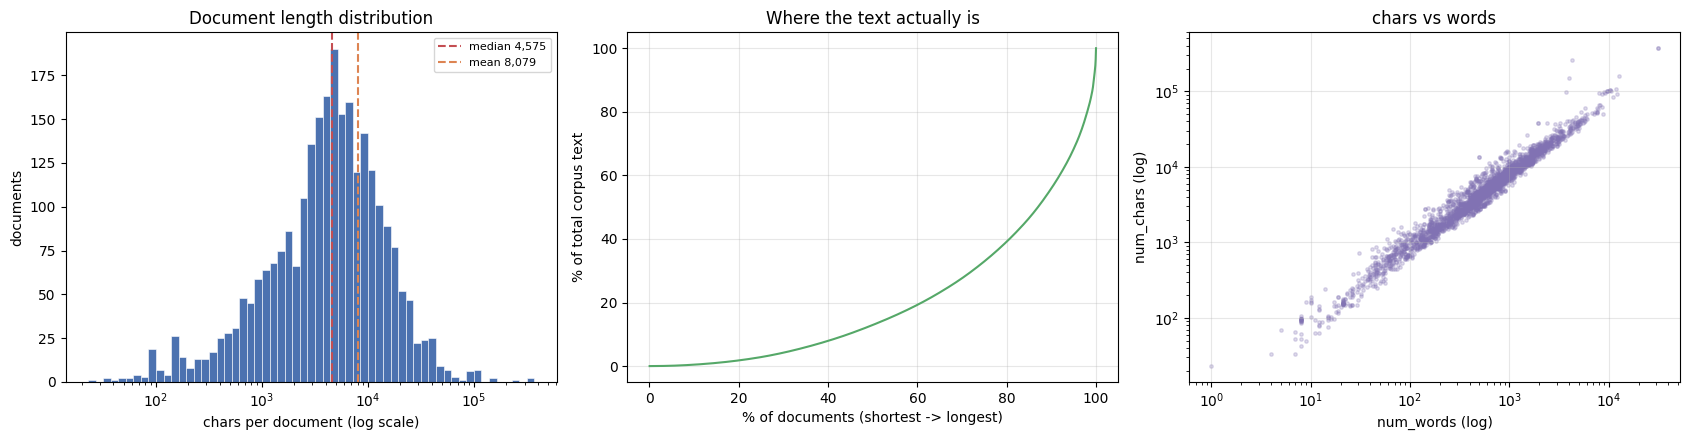


5 longest documents:
      num_chars  num_words                                                                          source
140      371057      31159                                        gradio-app/gradio/blob/main/CHANGELOG.md
2341     371057      31159                                 gradio-app/gradio/blob/main/gradio/CHANGELOG.md
1028     259303       4246  huggingface/hub-docs/blob/main/hacktoberfest_challenges/model_license_other.md
2233     157875      12589                    huggingface/diffusers/blob/main/examples/community/README.md
2498     150259       4024     huggingface/hub-docs/blob/main/hacktoberfest_challenges/model_no_license.md

5 shortest documents:
      num_chars  num_words                                                                 source
382          23          1                   gradio-app/gradio/blob/main/js/imageeditor/README.md
1878         33          4                         gradio-app/gradio/blob/main/js/theme/README.md
2577         33    

In [8]:
# --- length distribution ---
import numpy as np
import matplotlib.pyplot as plt

pcts = [50, 75, 90, 95, 99, 99.9, 100]
print("num_chars percentiles:")
for p in pcts:
    print(f"  p{p:<5} {np.percentile(docs_df['num_chars'], p):>12,.0f}")
print(f"\n  mean  {docs_df['num_chars'].mean():>12,.0f}")
print(f"  total {docs_df['num_chars'].sum():>12,.0f} chars across {len(docs_df):,} docs")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# 1. log-x histogram — a linear-x hist of this data is one bar and a rumour
bins = np.logspace(np.log10(max(docs_df['num_chars'].min(), 1)),
                   np.log10(docs_df['num_chars'].max()), 60)
axes[0].hist(docs_df['num_chars'], bins=bins, color='#4C72B0', edgecolor='white', linewidth=0.4)
axes[0].set_xscale('log')
axes[0].axvline(docs_df['num_chars'].median(), color='#C44E52', ls='--',
                label=f"median {docs_df['num_chars'].median():,.0f}")
axes[0].axvline(docs_df['num_chars'].mean(), color='#DD8452', ls='--',
                label=f"mean {docs_df['num_chars'].mean():,.0f}")
axes[0].set_xlabel('chars per document (log scale)')
axes[0].set_ylabel('documents')
axes[0].set_title('Document length distribution')
axes[0].legend(fontsize=8)

# 2. how much of the corpus lives in the long tail
s = np.sort(docs_df['num_chars'].values)
axes[1].plot(np.arange(1, len(s) + 1) / len(s) * 100,
             np.cumsum(s) / s.sum() * 100, color='#55A868')
axes[1].set_xlabel('% of documents (shortest -> longest)')
axes[1].set_ylabel('% of total corpus text')
axes[1].set_title('Where the text actually is')
axes[1].grid(alpha=0.3)

# 3. chars vs words — outliers off this line are code/CJK, not prose
axes[2].scatter(docs_df['num_words'], docs_df['num_chars'], s=6, alpha=0.25, color='#8172B3')
axes[2].set_xscale('log'); axes[2].set_yscale('log')
axes[2].set_xlabel('num_words (log)'); axes[2].set_ylabel('num_chars (log)')
axes[2].set_title('chars vs words')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n5 longest documents:")
print(docs_df.nlargest(5, 'num_chars')[['num_chars', 'num_words', 'source']].to_string())
print("\n5 shortest documents:")
print(docs_df.nsmallest(5, 'num_chars')[['num_chars', 'num_words', 'source']].to_string())

---
## 1.2 Tokenizer

The tokenizer is not a free choice: token counts must come from the *same* tokenizer the
embedding model was trained with, or the 510-token budget is measured in the wrong unit.

`use_fast=True` is required — only the Rust-backed fast tokenizers return
`offset_mapping`, which maps every token back to its character span in the source string.
That mapping is what lets the chunker cut on token boundaries while slicing text out of
the *original* document, avoiding a lossy `decode(encode(x))` round-trip.

In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

print(f"Model:          {MODEL_NAME}")
print(f"Vocab size:     {tokenizer.vocab_size:,}")
print(f"Model max len:  {tokenizer.model_max_length}")

Model:          BAAI/bge-base-en-v1.5
Vocab size:     30,522
Model max len:  512


**Offset mapping demo.** Each token carries the `(char_start, char_end)` span it came
from. Note that runs of whitespace consume no tokens at all — a WordPiece tokenizer
discards whitespace at pre-tokenization — so blank lines and indentation cost nothing
against the token budget.

In [10]:
demo_text = "Gradio Blocks\n\n\n    A low-level API for custom layouts."

demo_encoding = tokenizer(
    demo_text,
    return_offsets_mapping=True,   # fast tokenizers only
    add_special_tokens=False,      # exclude [CLS]/[SEP] so counts are content tokens
)

demo_tokens = tokenizer.convert_ids_to_tokens(demo_encoding["input_ids"])

print(f"{len(demo_tokens)} tokens for {len(demo_text)} chars\n")
for token, (span_start, span_end) in zip(demo_tokens, demo_encoding["offset_mapping"]):
    print(f"  {token:<12} ({span_start:>3}, {span_end:>3})  {demo_text[span_start:span_end]!r}")

# Whitespace is free: these two strings produce identical token counts.
print("\nwhitespace costs no tokens:",
      len(tokenizer.encode("hello\n\n\n\n\nworld")) == len(tokenizer.encode("hello world")))

14 tokens for 55 chars

  gr           (  0,   2)  'Gr'
  ##adi        (  2,   5)  'adi'
  ##o          (  5,   6)  'o'
  blocks       (  7,  13)  'Blocks'
  a            ( 20,  21)  'A'
  low          ( 22,  25)  'low'
  -            ( 25,  26)  '-'
  level        ( 26,  31)  'level'
  api          ( 32,  35)  'API'
  for          ( 36,  39)  'for'
  custom       ( 40,  46)  'custom'
  layout       ( 47,  53)  'layout'
  ##s          ( 53,  54)  's'
  .            ( 54,  55)  '.'

whitespace costs no tokens: True


---
## 1.3 Chunking

A sliding window over **tokens**, not characters, with every window carrying the lineage
needed to trace it back to its source document.

**Chunk size 500, overlap 64.**

- `bge-base-en-v1.5` has a 512-position limit, and the tokenizer spends 2 of those
  on `[CLS]` and `[SEP]` — so 510 content tokens is the true ceiling. 500 is used
  instead of 510, leaving 10 tokens of headroom so nothing is silently truncated.
- Fixed-size sliding window with overlap. Overlap 64 ≈ 13% of the window; it exists
  so a fact that straddles a boundary still appears whole in one of the two chunks.
- Every chunk carries `source`, `doc_id`, `chunk_index`, `char_start`, `char_end`,
  `n_tokens` and `total_chunks`. That lineage is what lets a retrieved chunk be
  cited back to a file and a character range, and it is what the Stage 5 labelled
  set indexes against.

In [11]:
def chunk_by_tokens(
    document_text: str,
    source: str,
    doc_id: int,
    tokenizer,
    chunk_size: int,
    chunk_overlap: int = 0,
) -> List[Dict[str, Any]]:
    """
    Split one document into overlapping, token-bounded chunks with lineage metadata.

    Windows are placed over the token sequence, but the chunk text is sliced out of the
    original string using each token's character offsets. Chunks are therefore exact
    substrings of `document_text` — no decode round-trip, and the character spans stay
    valid for citation.

    Parameters
    ----------
    document_text : str
        Full text of the source document.
    source : str
        Repository path of the document, carried into every chunk for citation.
    doc_id : int
        Identifier of the parent document, used to group chunks back to their origin.
    tokenizer : PreTrainedTokenizerFast
        A HuggingFace *fast* tokenizer; must support `return_offsets_mapping=True`.
    chunk_size : int
        Maximum content tokens per chunk, excluding [CLS]/[SEP].
    chunk_overlap : int, optional
        Tokens shared between consecutive chunks. Must be smaller than `chunk_size`,
        otherwise the window would never advance.

    Returns
    -------
    List[Dict[str, Any]]
        One record per chunk, each holding the chunk text alongside its lineage fields:
        `source`, `doc_id`, `chunk_index`, `total_chunks`, `char_start`, `char_end`,
        `n_tokens`, `text`. Empty list for an empty document.
    """
    if chunk_overlap >= chunk_size:
        raise ValueError("chunk_overlap must be less than chunk_size")

    chunk_records = []

    # Tokenize without special tokens; get offsets
    encoding = tokenizer(
        document_text,
        add_special_tokens=False,
        return_offsets_mapping=True
    )

    offsets = encoding["offset_mapping"]  # list of (char_start, char_end)
    total_doc_tokens = len(offsets)

    if total_doc_tokens == 0:
        return chunk_records

    stride = chunk_size - chunk_overlap
    chunk_index = 1

    start_token = 0
    while start_token < total_doc_tokens:
        end_token = min(start_token + chunk_size, total_doc_tokens)

        # Map token indices back to character spans in the original document
        char_start = offsets[start_token][0]
        char_end = offsets[end_token - 1][1]

        chunk_records.append({
            "source": source,
            "doc_id": doc_id,
            "chunk_index": chunk_index,
            "char_start": char_start,
            "char_end": char_end,
            "n_tokens": end_token - start_token,
            "text": document_text[char_start:char_end],
        })

        # If we have reached the end, stop; otherwise slide the window forward
        if end_token == total_doc_tokens:
            break
        start_token += stride
        chunk_index += 1

    for record in chunk_records:
        record["total_chunks"] = len(chunk_records)

    return chunk_records

`chunk_corpus` walks every document and assigns the corpus-wide `chunk_id`. The id is
assigned by the chunker rather than by the vector store, so it stays stable across
re-ingestion — two evaluation runs are only comparable if the same chunk keeps the same
identifier.


In [12]:
def chunk_corpus(
    docs_df: pd.DataFrame,
    tokenizer,
    chunk_size: int = CHUNK_SIZE,
    chunk_overlap: int = CHUNK_OVERLAP,
) -> List[Dict[str, Any]]:
    """
    Chunk every document in the corpus into a flat list of chunk records.

    Parameters
    ----------
    docs_df : pd.DataFrame
        Corpus with `text` and `source` columns, one row per document.
    tokenizer : PreTrainedTokenizerFast
        Fast tokenizer matching the embedding model.
    chunk_size, chunk_overlap : int
        Window size and overlap, in content tokens.

    Returns
    -------
    List[Dict[str, Any]]
        Every chunk in the corpus, each with a globally unique `chunk_id`. Text and
        metadata live in a single record, so they cannot drift out of alignment.
    """
    corpus_records = []
    chunk_id = 1

    for i in range(len(docs_df)):
        document_records = chunk_by_tokens(
            docs_df.iloc[i]["text"],
            docs_df.iloc[i]["source"],
            i + 1,
            tokenizer,
            chunk_size,
            chunk_overlap,
        )
        for record in document_records:
            record["chunk_id"] = chunk_id
            chunk_id += 1
        corpus_records.extend(document_records)

    return corpus_records

### Chunk persistence

Reader and writer are defined together, before either is used. The writer goes to a
temporary file and renames on success, so an interrupted write cannot leave a
half-finished artifact that a later stage would read as complete.

Both live here rather than in Stage 2 because §1.4 below already needs the reader: the
chunking cell reloads the artifact when it exists instead of rebuilding it.


In [13]:
import os


def save_chunks_jsonl(chunks: list[dict], output_path: str | Path) -> None:
    """
    Persist chunks as JSON Lines.
    Writes to a temporary file first so an interrupted write
    does not leave the main artifact in a partially written state.
    """

    output_path = Path(output_path)
    temp_path = output_path.with_suffix(".tmp")

    with open(temp_path, "w", encoding="utf-8") as f:
        for chunk in chunks:
            record = {
                key: value
                for key, value in chunk.items()
                if key != "embedding"
            }

            f.write(
                json.dumps(
                    record,
                    ensure_ascii=False
                ) + "\n"
            )

    os.replace(temp_path, output_path)

    print(f"Saved {len(chunks):,} chunks")
    print(f"Path: {output_path}")


def load_chunks_jsonl(input_path: str | Path) -> list[dict]:
    """Read a chunks.jsonl artifact back into a list of dicts."""

    chunks = []

    with open(
        input_path,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:
            chunks.append(
                json.loads(line)
            )

    return chunks


---
## 1.4 Chunk the full corpus

Chunks the corpus, or reloads `chunks.jsonl` if it already exists. Chunking is an
artifact, not a computation to repeat: the gold labels in Stage 5 are pinned to a hash of
this file, so regenerating it with different settings invalidates them.


In [14]:
if CHUNKS_PATH.exists() and not FORCE_RECHUNK:
    chunk_records = load_chunks_jsonl(CHUNKS_PATH)
    print(f"{len(chunk_records):,} chunks loaded from {CHUNKS_PATH.name} "
          f"(set FORCE_RECHUNK=True to rebuild)")
else:
    chunk_records = chunk_corpus(
        docs_df, tokenizer, chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP
    )
    print(f"{len(chunk_records):,} chunks from {len(docs_df):,} documents")

chunk_records[0]


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (642 > 512). Running this sequence through the model will result in indexing errors


16,071 chunks from 2,647 documents


{'source': 'huggingface/hf-endpoints-documentation/blob/main/docs/source/guides/create_endpoint.mdx',
 'doc_id': 1,
 'chunk_index': 1,
 'char_start': 1,
 'char_end': 1590,
 'n_tokens': 500,
 'text': 'Create an Endpoint\n\nAfter your first login, you will be directed to the [Endpoint creation page](https://ui.endpoints.huggingface.co/new). As an example, this guide will go through the steps to deploy [distilbert-base-uncased-finetuned-sst-2-english](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english) for text classification. \n\n## 1. Enter the Hugging Face Repository ID and your desired endpoint name:\n\n<img src="https://raw.githubusercontent.com/huggingface/hf-endpoints-documentation/main/assets/1_repository.png" alt="select repository" />\n\n## 2. Select your Cloud Provider and region. Initially, only AWS will be available as a Cloud Provider with the `us-east-1` and `eu-west-1` regions. We will add Azure soon, and if you need to test Endpoints with other Cloud P

### Chunk validation

Asserts unique IDs, no chunk over the token budget, every document represented, and every
chunk text an exact substring of its parent at the recorded span. The last one is what
makes `char_start`/`char_end` safe to cite from.

Slow (full corpus), so it sits behind `RUN_VALIDATION`. It must pass at least once.

In [15]:
def validate_chunk_keys(chunk: dict) -> None:
    """Assert the chunk carries every lineage field a citation depends on."""
    required_keys = {"doc_id", "text", "source", "char_start", "char_end","chunk_index", "chunk_id","n_tokens","total_chunks"}
    missing = required_keys - set(chunk.keys())
    assert not missing, f"Chunk missing metadata fields: {missing}, chunk={chunk}"

def validate_chunk_token_length(chunk: dict) -> None:
    """Assert the chunk fits the encoder budget, so nothing is silently truncated."""
    assert chunk['n_tokens'] <= CHUNK_SIZE, f"Chunk length is more than {CHUNK_SIZE}"

def validate_chunk_id(chunk: dict, id: int) -> None:
    """Assert chunk_id matches corpus position, so IDs stay stable across re-ingestion."""
    assert chunk['chunk_id'] == id, f"Chunk ID {chunk['chunk_id']} is equal to {id}"

def validate_every_document_has_atleast_one_chunk(
    docs_df: pd.DataFrame,
    chunks: list[dict],
) -> None:
    """Assert no document was dropped by the chunker."""
    per_doc_chunk_presence = {}
    for chunk in chunks:
        per_doc_chunk_presence[chunk['doc_id']] = True
    assert len(per_doc_chunk_presence) == len(docs_df), f"All docs doesn't contain atleast one chunk"

def validate_chunk_text_with_parent_document(
    docs_df: pd.DataFrame,
    chunks: list[dict],
) -> None:
    """Assert each chunk is an exact substring of its parent at the recorded span.

    This is what makes char_start/char_end safe to cite from.
    """
    for chunk in chunks:
        chunk_text = chunk['text']
        doc_id = chunk['doc_id']
        original_text = docs_df.iloc[doc_id-1]['text'][chunk['char_start']:chunk['char_end']]
        assert chunk_text == original_text, f"Chunk ID: {chunk['chunk_id']} text doesn't match with it's parent document text"


In [16]:
if RUN_VALIDATION:
    for id,chunk in enumerate(chunk_records):
        validate_chunk_id(chunk, id+1)
        validate_chunk_token_length(chunk)
        validate_chunk_keys(chunk)

    validate_every_document_has_atleast_one_chunk(docs_df,chunk_records)
    validate_chunk_text_with_parent_document(docs_df,chunk_records)
    print("Chunk validation passed.")
else:
    print("RUN_VALIDATION=False — skipping the full-corpus sweep. "
          "Set it True to re-prove chunk integrity.")

Chunk validation passed.


### Persist the chunks

Writes the artifact with the helper defined above. One JSON object per line, so the file
streams and a single malformed record is recoverable. Every downstream stage reads from
here rather than from memory.


In [17]:
save_chunks_jsonl(
    chunk_records,
    CHUNKS_PATH
)

Saved 16,071 chunks
Path: /Users/manishdiddi/Documents/AI ML Projects/AI Engineering/Domain Specific RAG/processed/chunks.jsonl


In [18]:
def validate_chunks(chunks: list[dict]) -> None:
    """Assert the invariants every downstream stage relies on.

    Unique chunk_id, non-empty text, positive token count. Raises rather than
    returning a flag, because a corpus that fails these should not be embedded.
    """

    assert len(chunks) > 0, "No chunks found."

    chunk_ids = [
        chunk["chunk_id"]
        for chunk in chunks
    ]

    assert len(chunk_ids) == len(set(chunk_ids)), \
        "Duplicate chunk_id detected."

    for chunk in chunks:

        assert chunk["text"].strip(), \
            f"Empty text for chunk {chunk['chunk_id']}"

        assert chunk["n_tokens"] > 0, \
            f"Invalid token count for chunk {chunk['chunk_id']}"

    print("Stage 1 validation passed.")
    print(f"Total chunks: {len(chunks):,}")


if RUN_VALIDATION:
    validate_chunks(chunk_records)
else:
    print(f"RUN_VALIDATION=False — skipped. {len(chunk_records):,} chunks in memory.")

Stage 1 validation passed.
Total chunks: 16,071


In [19]:
n_tokens = [c["n_tokens"] for c in chunk_records]

checkpoint(
    "Stage 1 — data processing & chunking",
    documents_in=f"{len(docs_df):,}",
    documents_represented=f"{len({c['doc_id'] for c in chunk_records}):,}",
    chunks_out=f"{len(chunk_records):,}",
    window=f"{CHUNK_SIZE} tokens, {CHUNK_OVERLAP} overlap ({CHUNK_OVERLAP / CHUNK_SIZE:.0%})",
    tokens_per_chunk=f"min {min(n_tokens)}, mean {sum(n_tokens) / len(n_tokens):.0f}, max {max(n_tokens)}",
    over_budget=f"{sum(t > CHUNK_SIZE for t in n_tokens)}  (must be 0)",
    artifact=f"{CHUNKS_PATH.name}  {artifact_size(CHUNKS_PATH)}",
)



--------------------------------------------------------------------
Stage 1 — data processing & chunking
--------------------------------------------------------------------
  documents in           2,647
  documents represented  2,647
  chunks out             16,071
  window                 500 tokens, 64 overlap (13%)
  tokens per chunk       min 9, mean 461, max 500
  over budget            0  (must be 0)
  artifact               chunks.jsonl  28.5 MB



## 1.5 Chunking report

Six panels describing the chunk population. Panel 2 is the one that decides whether the
chunker is correct: every bar must sit at or left of the `CHUNK_SIZE` line, which is the
visual proof that no chunk will be silently truncated by the encoder. Panel 5 sizes the
population of very short trailing chunks, and panel 6 the non-English share of the corpus.


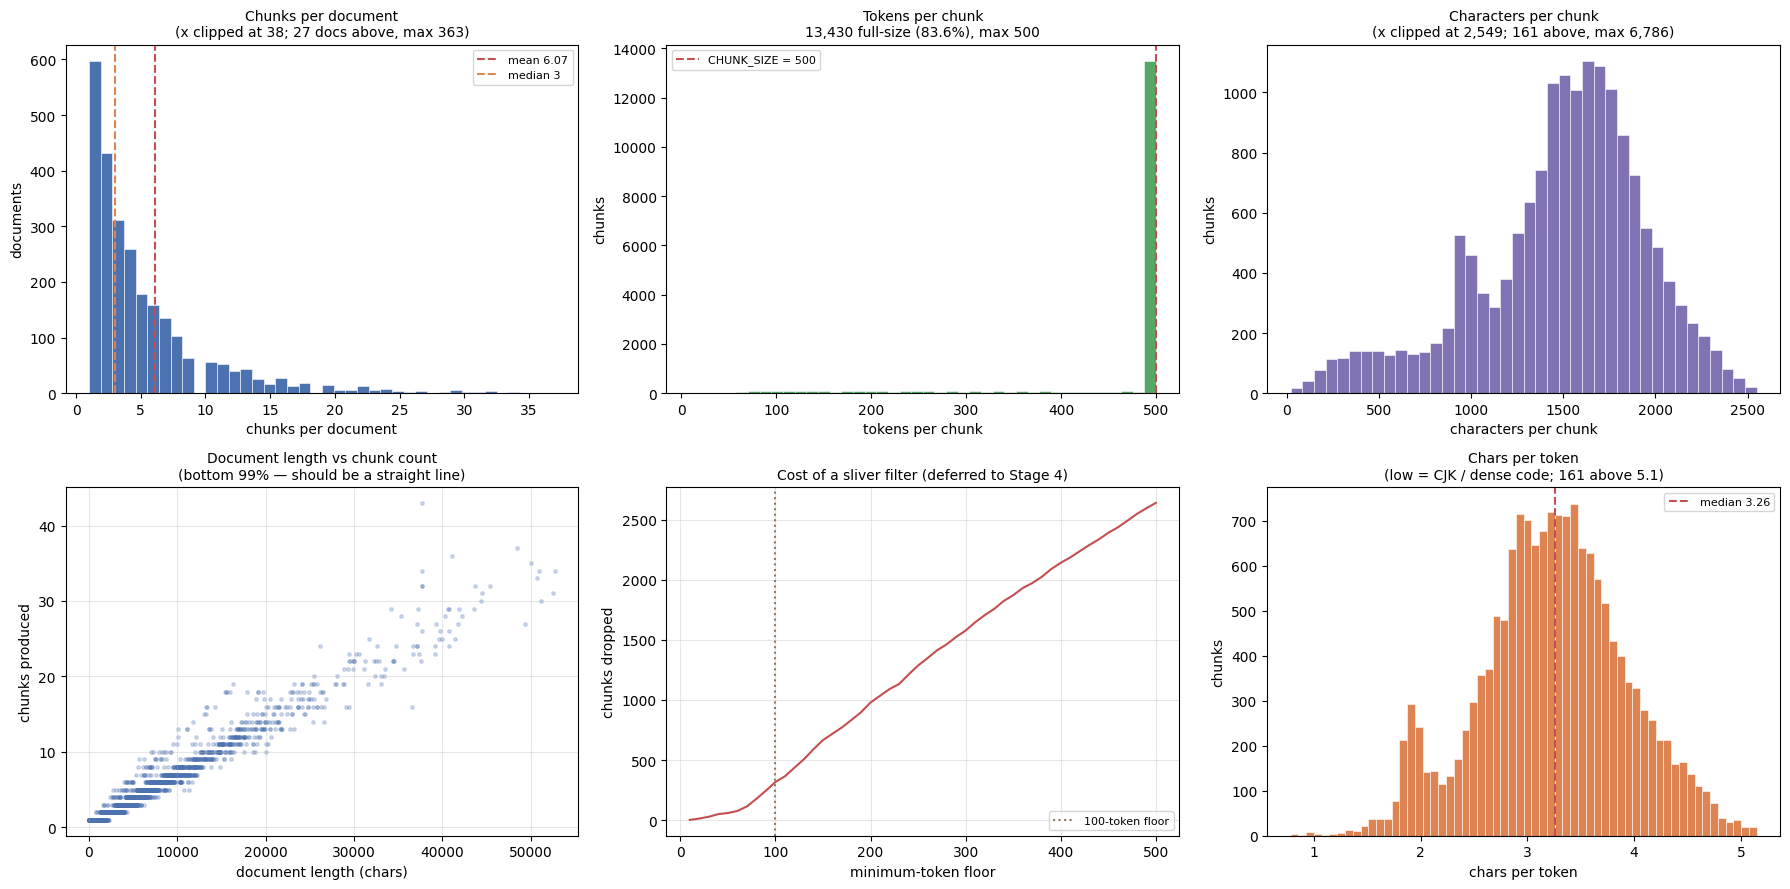

       chunks_per_doc  tokens_per_chunk  chars_per_chunk  chars_per_token
count         2647.00          16071.00         16071.00         16071.00
mean             6.07            460.90          1502.61             3.26
std             12.98            102.49           484.97             0.75
min              1.00              9.00            21.00             0.78
50%              3.00            500.00          1559.00             3.26
90%             12.00            500.00          2035.00             4.16
99%             37.54            500.00          2549.30             5.15
max            363.00            500.00          6786.00            13.57

total chunks          16,071
total documents       2,647
full-size chunks      13,430 (83.6%)
max chunk chars       6,786 
chunks < 100 tokens   317 (1.97%)


In [20]:
# --- chunk distribution analysis ---
# Linear axes throughout. Where a long tail would flatten the plot, the x-axis is
# clipped to the 99th percentile and the excluded count is stated in the title.
chunk_df = pd.DataFrame(chunk_records)

chunks_per_doc = chunk_df.groupby("doc_id").size()
chunk_chars = chunk_df["char_end"] - chunk_df["char_start"]
chars_per_token = chunk_chars / chunk_df["n_tokens"]
doc_chars = pd.Series(docs_df["num_chars"].values[chunks_per_doc.index - 1],
                      index=chunks_per_doc.index)


def clipped(
    ax: "plt.Axes",
    values: "np.ndarray | list[float]",
    p: int = 99,
    bins: int = 40,
    color: str = "#4C72B0",
) -> None:
    """Histogram the bulk of a skewed distribution; return how many rows were cut."""
    cutoff = np.percentile(values, p)
    kept = values[values <= cutoff]
    ax.hist(kept, bins=bins, color=color, edgecolor="white", linewidth=0.4)
    return int((values > cutoff).sum()), cutoff


fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# 1. chunks per document
n_cut, cutoff = clipped(axes[0, 0], chunks_per_doc, p=99)
axes[0, 0].axvline(chunks_per_doc.mean(), color="#C44E52", ls="--",
                   label=f"mean {chunks_per_doc.mean():.2f}")
axes[0, 0].axvline(chunks_per_doc.median(), color="#DD8452", ls="--",
                   label=f"median {chunks_per_doc.median():.0f}")
axes[0, 0].set_xlabel("chunks per document")
axes[0, 0].set_ylabel("documents")
axes[0, 0].set_title(f"Chunks per document\n(x clipped at {cutoff:.0f}; "
                     f"{n_cut} docs above, max {chunks_per_doc.max():,})", fontsize=10)
axes[0, 0].legend(fontsize=8)

# 2. tokens per chunk — the safety plot. Nothing may sit right of CHUNK_SIZE.
n_full = int((chunk_df["n_tokens"] == CHUNK_SIZE).sum())
axes[0, 1].hist(chunk_df["n_tokens"], bins=40, color="#55A868", edgecolor="white", linewidth=0.4)
axes[0, 1].axvline(CHUNK_SIZE, color="#C44E52", ls="--", label=f"CHUNK_SIZE = {CHUNK_SIZE}")
axes[0, 1].set_xlabel("tokens per chunk")
axes[0, 1].set_ylabel("chunks")
axes[0, 1].set_title(f"Tokens per chunk\n{n_full:,} full-size ({n_full / len(chunk_df):.1%}), "
                     f"max {chunk_df['n_tokens'].max()}", fontsize=10)
axes[0, 1].legend(fontsize=8)

# 3. characters per chunk
n_cut, cutoff = clipped(axes[0, 2], chunk_chars, p=99, color="#8172B3")
axes[0, 2].set_xlabel("characters per chunk")
axes[0, 2].set_ylabel("chunks")
axes[0, 2].set_title(f"Characters per chunk\n(x clipped at {cutoff:,.0f}; "
                     f"{n_cut} above, max {chunk_chars.max():,})", fontsize=10)

# 4. sanity check: chunk count should rise linearly with document length
mask = (doc_chars <= np.percentile(doc_chars, 99))
axes[1, 0].scatter(doc_chars[mask], chunks_per_doc[mask], s=6, alpha=0.25, color="#4C72B0")
axes[1, 0].set_xlabel("document length (chars)")
axes[1, 0].set_ylabel("chunks produced")
axes[1, 0].set_title("Document length vs chunk count\n(bottom 99% — should be a straight line)",
                     fontsize=10)
axes[1, 0].grid(alpha=0.3)

# 5. how many chunks a minimum-token floor would remove, at each threshold
thresholds = np.arange(10, CHUNK_SIZE + 1, 10)
below = [(chunk_df["n_tokens"] < t).sum() for t in thresholds]
axes[1, 1].plot(thresholds, below, color="#C44E52")
axes[1, 1].axvline(100, color="#937860", ls=":", label="100-token floor")
axes[1, 1].set_xlabel("minimum-token floor")
axes[1, 1].set_ylabel("chunks dropped")
axes[1, 1].set_title("Cost of a sliver filter (deferred to Stage 4)", fontsize=10)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend(fontsize=8)

# 6. chars-per-token per chunk — low values are CJK or dense code
n_cut, cutoff = clipped(axes[1, 2], chars_per_token, p=99, bins=60, color="#DD8452")
axes[1, 2].axvline(chars_per_token.median(), color="#C44E52", ls="--",
                   label=f"median {chars_per_token.median():.2f}")
axes[1, 2].set_xlabel("chars per token")
axes[1, 2].set_ylabel("chunks")
axes[1, 2].set_title(f"Chars per token\n(low = CJK / dense code; {n_cut} above {cutoff:.1f})",
                     fontsize=10)
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- raw numbers ---------------------------------------------------------------
summary = pd.DataFrame({
    "chunks_per_doc": chunks_per_doc.describe(percentiles=[.5, .9, .99]),
    "tokens_per_chunk": chunk_df["n_tokens"].describe(percentiles=[.5, .9, .99]),
    "chars_per_chunk": chunk_chars.describe(percentiles=[.5, .9, .99]),
    "chars_per_token": chars_per_token.describe(percentiles=[.5, .9, .99]),
}).round(2)
print(summary.to_string())

print(f"\ntotal chunks          {len(chunk_df):,}")
print(f"total documents       {chunks_per_doc.size:,}")
print(f"full-size chunks      {n_full:,} ({n_full / len(chunk_df):.1%})")
print(f"max chunk chars       {chunk_chars.max():,} ")
print(f"chunks < 100 tokens   {(chunk_df['n_tokens'] < 100).sum():,} "
      f"({(chunk_df['n_tokens'] < 100).mean():.2%})")

---
# Stage 2 — Vectorization & the Vector Store

16,071 chunks become 768-dim unit-length vectors, persisted to disk, then loaded into a
Qdrant collection with their lineage metadata.

**In:** `chunks.jsonl`.  **Out:** `embeddings.npy` (16,071 x 768 unit-norm vectors) and a populated Qdrant collection keyed by `chunk_id`.


## 2.1 Embedding model

`BAAI/bge-base-en-v1.5`, 768 dimensions, with `normalize_embeddings=True`.

Normalising to unit length is what makes inner product identical to cosine similarity, so
the vector store can use the cheaper metric without changing the ranking. The same model
supplies the tokenizer used in Stage 1, so token counts and the 512-position limit are
measured in the same unit the encoder enforces.


### Load the chunks from disk

Read back from `chunks.jsonl` with the loader defined in §1.3, rather than reusing the
in-memory list, so this stage runs correctly from a restarted kernel.


In [21]:
chunks = load_chunks_jsonl(CHUNKS_PATH)

print(f"Loaded {len(chunks):,} chunks")

Loaded 16,071 chunks


### Load the encoder

`SentenceTransformer` loads the same model whose tokenizer measured the chunks in Stage 1,
so the 512-position limit is enforced in the unit it was budgeted in.


In [22]:
# Task 2.1 — load the embedding model

model = SentenceTransformer(MODEL_NAME)

EMBEDDING_DIMENSION = model.get_sentence_embedding_dimension()

# Guard against a silent model swap: every persisted artifact (embeddings.npy,
# the Qdrant collection, the Stage 5 gold chunk ids) is only valid for the model
# and width recorded in the manifests.
assert EMBEDDING_DIMENSION == 768, (
    f"Expected 768-dim vectors from {MODEL_NAME}, got {EMBEDDING_DIMENSION}. "
    "Re-embedding is required before any stored index can be reused."
)

print("Model                :", MODEL_NAME)
print("Embedding dimension  :", EMBEDDING_DIMENSION)
print("Max sequence length  :", model.max_seq_length)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model                : BAAI/bge-base-en-v1.5
Embedding dimension  : 768
Max sequence length  : 512


/var/folders/rt/mvnm7dxx3fq528n9njvz70wc0000gn/T/ipykernel_28307/3614897178.py:5: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  EMBEDDING_DIMENSION = model.get_sentence_embedding_dimension()


### Token-budget check

Re-tokenises every chunk and asserts none exceeds the encoder's limit. The chunker already
guarantees this; the check is here because truncation would be silent — the encoder drops
the overflow and returns a vector either way.


In [23]:
sample_text = chunks[0]["text"]

tokenized = model.tokenizer(
    sample_text,
    truncation=False,
    add_special_tokens=True
)

print(
    "Actual tokenizer sequence length:",
    len(tokenized["input_ids"])
)

print(
    "Model max sequence length:",
    model.max_seq_length
)

Actual tokenizer sequence length: 502
Model max sequence length: 512


In [24]:
# Re-tokenises all 16,071 chunks to prove none exceeds the encoder's limit. The chunker
# already guarantees this by construction; the sweep is independent confirmation.
if RUN_VALIDATION:
    max_actual_length = 0
    problematic_chunks = []

    for chunk in chunks:

        tokenized = model.tokenizer(
            chunk["text"],
            truncation=False,
            add_special_tokens=True
        )

        length = len(tokenized["input_ids"])

        max_actual_length = max(
            max_actual_length,
            length
        )

        if length > model.max_seq_length:
            problematic_chunks.append(
                (
                    chunk["chunk_id"],
                    length
                )
            )

    print(
        "Maximum actual sequence length:",
        max_actual_length
    )

    print(
        "Problematic chunks:",
        len(problematic_chunks)
    )

    assert not problematic_chunks, (
        f"Found {len(problematic_chunks)} chunks "
        f"exceeding model max length."
    )
else:
    print("RUN_VALIDATION=False — skipping the token-length sweep.")

Maximum actual sequence length: 505
Problematic chunks: 0


### Batch-encode and persist

`batch_size=64` bounds peak memory by the batch rather than the corpus — encoding 16,071
chunks in one call is how a session dies with an OOM.

The vectors are an artifact, not a computation to repeat. They are written to
`embeddings.npy` and every stage below loads from disk: re-encoding costs minutes, and a
recomputed vector set is a *different* set if the model version moved, which would
invalidate the gold labels pinned to the corpus hash.


In [25]:
# The single most expensive cell in the notebook. Vectors are an artifact, not a
# computation to repeat: re-encoding is minutes of CPU, and a recomputed vector set is a
# *different* vector set if anything about the model or its version moved — which would
# silently invalidate every gold label pinned to the corpus hash.
if EMBEDDINGS_PATH.exists() and not FORCE_REEMBED:
    embeddings = np.load(EMBEDDINGS_PATH)
    print(f"Loaded {embeddings.shape[0]:,} x {embeddings.shape[1]} vectors from "
          f"{EMBEDDINGS_PATH.name} (set FORCE_REEMBED=True to re-encode)")
    assert len(embeddings) == len(chunks), (
        f"{len(embeddings):,} vectors but {len(chunks):,} chunks — the persisted "
        "embeddings do not match this corpus. Re-embed with FORCE_REEMBED=True."
    )
else:
    texts = [chunk["text"] for chunk in chunks]
    embeddings = model.encode(
        texts,
        batch_size=64,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=True,
    )

Batches:   0%|          | 0/252 [00:00<?, ?it/s]

In [26]:
embeddings = np.asarray(
    embeddings,
    dtype=np.float32
)

print("Embedding shape:", embeddings.shape)
print("Embedding dtype:", embeddings.dtype)

Embedding shape: (16071, 768)
Embedding dtype: float32


In [27]:
norms = np.linalg.norm(
    embeddings,
    axis=1
)

print("Minimum norm:", norms.min())
print("Maximum norm:", norms.max())
print("Mean norm:", norms.mean())

Minimum norm: 0.9999999
Maximum norm: 1.0000001
Mean norm: 1.0


### Persist the vectors

`embeddings.npy` is the expensive artifact. Every stage below loads it instead of
re-encoding.


In [28]:
np.save(
    EMBEDDINGS_PATH,
    embeddings
)

print(
    f"Saved embeddings to:\n{EMBEDDINGS_PATH}"
)

Saved embeddings to:
/Users/manishdiddi/Documents/AI ML Projects/AI Engineering/Domain Specific RAG/processed/embeddings.npy


### Persist the matching chunk IDs

Row *i* of the embedding matrix belongs to chunk ID *i* of this array. That pairing is the
only thing linking a vector to its text, so it is stored explicitly rather than left
implicit in list order.


In [29]:
embedding_chunk_ids = np.asarray(
    [
        chunk["chunk_id"]
        for chunk in chunks
    ],
    dtype=np.int64
)

np.save(
    EMBEDDING_IDS_PATH,
    embedding_chunk_ids
)

In [30]:
checkpoint(
    "Stage 2.1 — vectorization",
    model=MODEL_NAME,
    vectors=f"{embeddings.shape[0]:,}",
    chunks_to_match=f"{len(chunks):,}",
    embedding_dimension=embeddings.shape[1],
    dtype=str(embeddings.dtype),
    unit_norm=f"min {norms.min():.6f}, max {norms.max():.6f}  (must be ~1.0)",
    ids_aligned=len(embedding_chunk_ids) == embeddings.shape[0],
    artifact=f"{EMBEDDINGS_PATH.name}  {artifact_size(EMBEDDINGS_PATH)}",
)



--------------------------------------------------------------------
Stage 2.1 — vectorization
--------------------------------------------------------------------
  model                BAAI/bge-base-en-v1.5
  vectors              16,071
  chunks to match      16,071
  embedding dimension  768
  dtype                float32
  unit norm            min 1.000000, max 1.000000  (must be ~1.0)
  ids aligned          True
  artifact             embeddings.npy  49.4 MB



---
## 2.2 Vector store — Qdrant ingestion

Vectors and payloads are loaded from disk and upserted in batches, then verified three
ways: point count, ID integrity, index config.

| choice | value | why |
|---|---|---|
| point ID | `chunk_id` from the chunker | database-generated IDs change on re-ingest, so two eval runs stop being comparable |
| payload | `source`, `doc_id`, `chunk_index`, `char_start`, `char_end`, `n_tokens`, `total_chunks` | lets a retrieved chunk be cited back to a file and character range |
| metric | `Distance.DOT` | identical to cosine on unit-norm vectors, two norm computations cheaper |
| index | HNSW | approximate search; exact scan over 16k is fine but does not generalise |

The brief specifies Milvus. The substitution to Qdrant, what it preserves and what it
costs, is documented in **Design substitutions and trade-offs** at the end of the notebook.


In [31]:
from qdrant_client import QdrantClient, models
import numpy as np
import json
from pathlib import Path

In [32]:
# Defined in the Configuration cell at the top; re-stated here so this stage can
# be read on its own.
print("Qdrant path     :", QDRANT_PATH)
print("Collection name :", COLLECTION_NAME)

Qdrant path     : /Users/manishdiddi/Documents/AI ML Projects/AI Engineering/Domain Specific RAG/processed/qdrant_db
Collection name : bcs_chunks


### Load chunks and vectors

Both are read from disk and checked against each other before anything is written to the
database: equal lengths, and an embedding width matching the collection dimension.


In [33]:
# load_chunks_jsonl() is defined once, in Stage 2.1. Re-loading from disk here
# (rather than reusing the in-memory list) is deliberate: it proves the persisted
# artifacts alone are enough to rebuild the index with no earlier cell in memory.
chunks = load_chunks_jsonl(CHUNKS_PATH)

embeddings = np.load(EMBEDDINGS_PATH)
embedding_chunk_ids = np.load(EMBEDDING_IDS_PATH)

print("Chunks:    ", len(chunks))
print("Embeddings:", embeddings.shape)
print("IDs:       ", embedding_chunk_ids.shape)

Chunks:     16071
Embeddings: (16071, 768)
IDs:        (16071,)


In [34]:
assert len(chunks) == len(embeddings)
assert len(chunks) == len(embedding_chunk_ids)

assert embeddings.ndim == 2
assert embeddings.shape[1] == EMBEDDING_DIMENSION

chunk_ids = np.asarray(
    [chunk["chunk_id"] for chunk in chunks],
    dtype=np.int64
)

assert np.array_equal(
    chunk_ids,
    embedding_chunk_ids
)

assert len(np.unique(embedding_chunk_ids)) == len(
    embedding_chunk_ids
)

print("Pre-insertion validation passed.")

Pre-insertion validation passed.


In [35]:
qdrant_client = QdrantClient(
    path=str(QDRANT_PATH)
)

print("Qdrant client initialized.")

Qdrant client initialized.


### Create the collection

Vector size and distance metric are fixed at creation and cannot be changed afterwards, so
a mismatch here surfaces as silently wrong rankings rather than an error.


In [36]:
if qdrant_client.collection_exists(COLLECTION_NAME):
    print(
        f"Collection '{COLLECTION_NAME}' already exists."
    )
else:
    qdrant_client.create_collection(
        collection_name=COLLECTION_NAME,

        vectors_config=models.VectorParams(
            size=EMBEDDING_DIMENSION,
            distance=models.Distance.DOT,
        ),

        hnsw_config=models.HnswConfigDiff(),
    )

    print(
        f"Created collection '{COLLECTION_NAME}'."
    )

Created collection 'bcs_chunks'.


### Insert vectors in batches

Batched upserts bound the size of any single request. Upsert is keyed on `chunk_id`, so
re-running overwrites rather than duplicates.


In [37]:
DB_BATCH_SIZE = 256

In [38]:
# Ingestion is idempotent by point ID, so re-running is safe — but it is also a minute
# of needless work on every restart. Skip when the collection already holds this corpus.
_existing = qdrant_client.get_collection(COLLECTION_NAME).points_count

if _existing == len(chunks) and not FORCE_REINGEST:
    print(f"Collection already holds {_existing:,} points — skipping ingestion "
          f"(set FORCE_REINGEST=True to re-upload).")
else:
    print(f"Ingesting {len(chunks):,} points (collection currently has {_existing:,})")

    for start in range(
        0,
        len(chunks),
        DB_BATCH_SIZE
    ):

        end = min(
            start + DB_BATCH_SIZE,
            len(chunks)
        )

        points = []

        for i in range(start, end):

            chunk = chunks[i]

            points.append(
                models.PointStruct(
                    id=int(chunk["chunk_id"]),

                    vector=embeddings[i].tolist(),

                    payload={
                        "text": chunk["text"],
                        "source": chunk["source"],
                        "doc_id": chunk["doc_id"],
                        "chunk_index": chunk["chunk_index"],
                        "char_start": chunk["char_start"],
                        "char_end": chunk["char_end"],
                        "n_tokens": chunk["n_tokens"],
                        "total_chunks": chunk["total_chunks"],
                    }
                )
            )

        qdrant_client.upload_points(
            collection_name=COLLECTION_NAME,
            points=points,
            batch_size=DB_BATCH_SIZE,
            wait=True,
        )

        print(
            f"Uploaded {end:,}/{len(chunks):,}"
        )

Ingesting 16,071 points (collection currently has 0)
Uploaded 256/16,071
Uploaded 512/16,071
Uploaded 768/16,071
Uploaded 1,024/16,071
Uploaded 1,280/16,071
Uploaded 1,536/16,071
Uploaded 1,792/16,071
Uploaded 2,048/16,071
Uploaded 2,304/16,071
Uploaded 2,560/16,071
Uploaded 2,816/16,071
Uploaded 3,072/16,071
Uploaded 3,328/16,071
Uploaded 3,584/16,071
Uploaded 3,840/16,071
Uploaded 4,096/16,071
Uploaded 4,352/16,071
Uploaded 4,608/16,071
Uploaded 4,864/16,071
Uploaded 5,120/16,071
Uploaded 5,376/16,071
Uploaded 5,632/16,071
Uploaded 5,888/16,071
Uploaded 6,144/16,071
Uploaded 6,400/16,071
Uploaded 6,656/16,071
Uploaded 6,912/16,071
Uploaded 7,168/16,071
Uploaded 7,424/16,071
Uploaded 7,680/16,071
Uploaded 7,936/16,071
Uploaded 8,192/16,071
Uploaded 8,448/16,071
Uploaded 8,704/16,071
Uploaded 8,960/16,071
Uploaded 9,216/16,071
Uploaded 9,472/16,071
Uploaded 9,728/16,071
Uploaded 9,984/16,071
Uploaded 10,240/16,071
Uploaded 10,496/16,071
Uploaded 10,752/16,071
Uploaded 11,008/16,071
Upl

### Verify the vector count

A partial ingest is not visible from the client — the call returns successfully either
way. Only the stored count proves every chunk arrived.


In [39]:
collection_info = qdrant_client.get_collection(
    COLLECTION_NAME
)

print(
    "Vectors in Qdrant:",
    collection_info.points_count
)

print(
    "Expected:",
    len(chunks)
)

Vectors in Qdrant: 16071
Expected: 16071


In [40]:
assert collection_info.points_count == len(chunks), (
    f"Count mismatch: "
    f"{collection_info.points_count} != {len(chunks)}"
)

print("Vector count validation passed.")

Vector count validation passed.


### Verify that IDs weren't dropped

Counts can match while the contents differ. Scrolling the full ID set and comparing it to
the chunker's IDs is what rules that out.


In [41]:
stored_ids = set()

offset = None

while True:

    records, next_offset = qdrant_client.scroll(
        collection_name=COLLECTION_NAME,
        limit=1000,
        offset=offset,
        with_vectors=False,
        with_payload=False,
    )

    for record in records:
        stored_ids.add(int(record.id))

    if next_offset is None:
        break

    offset = next_offset

In [42]:
expected_ids = set(
    int(chunk["chunk_id"])
    for chunk in chunks
)

assert stored_ids == expected_ids

print("ID integrity validation passed.")

ID integrity validation passed.


### Verify HNSW configuration

Confirms the stored metric and index parameters are the ones intended, since both are
fixed at creation.


In [43]:
info = qdrant_client.get_collection(
    COLLECTION_NAME
)

print(info.config.hnsw_config)
print(info.config.params.vectors)  # or named vectors config

m=16 ef_construct=100 full_scan_threshold=10000 max_indexing_threads=0 on_disk=None memory=None payload_m=None inline_storage=None
size=768 distance=<Distance.DOT: 'Dot'> hnsw_config=None quantization_config=None on_disk=None memory=None datatype=None multivector_config=None


In [44]:
_info = qdrant_client.get_collection(COLLECTION_NAME)
_sample = qdrant_client.scroll(COLLECTION_NAME, limit=1, with_payload=True)[0][0]

checkpoint(
    "Stage 2.2 — vector store",
    collection=COLLECTION_NAME,
    records_inserted=f"{_info.points_count:,}",
    expected=f"{len(chunks):,}",
    complete=_info.points_count == len(chunks),
    vector_size=_info.config.params.vectors.size,
    distance=str(_info.config.params.vectors.distance),
    hnsw=f"m={_info.config.hnsw_config.m}, ef_construct={_info.config.hnsw_config.ef_construct}",
    payload_fields=", ".join(sorted(_sample.payload)),
)



--------------------------------------------------------------------
Stage 2.2 — vector store
--------------------------------------------------------------------
  collection        bcs_chunks
  records inserted  16,071
  expected          16,071
  complete          True
  vector size       768
  distance          Dot
  hnsw              m=16, ef_construct=100
  payload fields    char_end, char_start, chunk_index, doc_id, n_tokens, source, text, total_chunks



---
# Stage 3 — Retrieval

**In:** a natural-language question and the Qdrant collection.  **Out:** the top-k chunks, each with its similarity score and lineage payload.


## 3.1 Asymmetric query encoding

BGE is trained as a query → passage retriever, not a symmetric similarity model. Passages
are encoded raw; queries get an instruction prefix, which moves a short query into the
region of the space the model learned to match long passages against.

Encoding both sides the same way degrades ranking silently — nothing errors, the scores
just get worse.

`USE_QUERY_INSTRUCTION` is a switch rather than a constant because BAAI report v1.5 also
works without the prefix, so the gain is corpus-dependent. Measured in §5.2.


In [45]:
from typing import Any

# BAAI's published retrieval instruction for the bge-*-en-v1.5 family.
# Applied to QUERIES ONLY — passages in cell 41 are encoded raw.
BGE_QUERY_INSTRUCTION = "Represent this sentence for searching relevant passages: "
USE_QUERY_INSTRUCTION = True


def embed_query(query: str, use_instruction: bool = USE_QUERY_INSTRUCTION):
    """Encode a query the way BGE expects: instruction-prefixed and unit-norm."""
    text = f"{BGE_QUERY_INSTRUCTION}{query}" if use_instruction else query
    return model.encode(
        text,
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype("float32")


def search_vector_db(
    query: str,
    qdrant_client = qdrant_client,
    top_k: int = 5,
    use_instruction: bool = USE_QUERY_INSTRUCTION,
) -> list[dict[str, Any]]:
    """
    Embed the query and search the Qdrant collection.

    Args:
        query: Natural-language search query.
        top_k: Number of most similar chunks to retrieve.
        use_instruction: Prepend the BGE retrieval instruction. Exposed so the
            with/without comparison can be measured, not assumed.

    Returns:
        A list of dictionaries containing:
        - chunk_id
        - score
        - text
        - source
    """

    if not query or not query.strip():
        raise ValueError("Query must not be empty.")

    if top_k <= 0:
        raise ValueError("top_k must be greater than 0.")

    query_embedding = embed_query(query, use_instruction=use_instruction)

    results = qdrant_client.query_points(
        collection_name=COLLECTION_NAME,
        query=query_embedding.tolist(),
        limit=top_k,
        with_payload=["text", "source"],
        with_vectors=False,
    )

    search_results = []

    for point in results.points:
        search_results.append(
            {
                "chunk_id": point.id,
                "score": float(point.score),
                "text": point.payload.get("text"),
                "source": point.payload.get("source"),
            }
        )

    return search_results

## 3.2 Retrieval check

One query through `search_vector_db`, to confirm the collection answers and that the
payload carries the lineage fields the later stages depend on.


In [46]:
results = search_vector_db(
    qdrant_client=qdrant_client,
    query="How do I configure and create a Hugging Face Inference Endpoint, including the instance configuration, security settings, and final endpoint creation?",
    top_k=5,
)

for i, result in enumerate(results, start=1):
    print(f"Rank: {i}")
    print(f"Chunk ID: {result['chunk_id']}")
    print(f"Score: {result['score']:.4f}")
    print(f"Source: {result['source']}")
    print(f"Text: {result['text'][:500]}")
    print("-" * 80)

Rank: 1
Chunk ID: 15052
Score: 0.8377
Source: huggingface/blog/blob/main/inference-endpoints-embeddings.md
Text: create embeddings](#4-send-request-to-endpoint-and-create-embeddings)

Before we start, let's refresh our knowledge about Inference Endpoints.

## 1. What is Hugging Face Inference Endpoints?

[Hugging Face Inference Endpoints](https://ui.endpoints.huggingface.co/) offers an easy and secure way to deploy Machine Learning models for use in production. Inference Endpoints empower developers and data scientists to create Generative AI applications without managing infrastructure: simplifying the de
--------------------------------------------------------------------------------
Rank: 2
Chunk ID: 718
Score: 0.8297
Source: huggingface/blog/blob/main/inference-endpoints-llm.md
Text: What is Hugging Face Inference Endpoints

[Hugging Face Inference Endpoints](https://ui.endpoints.huggingface.co/) offers an easy and secure way to deploy Machine Learning models for use in production.

In [47]:
PROBE_K = 5   # provisional; the depth used for every measured result is chosen in §5.2
_probe = search_vector_db(query="how do i push over ssh", top_k=PROBE_K)

checkpoint(
    "Stage 3 — retrieval",
    top_k=f"{PROBE_K}  (provisional — measured and fixed in §5.2)",
    query_instruction=USE_QUERY_INSTRUCTION,
    results_returned=len(_probe),
    score_range=f"{min(h['score'] for h in _probe):.4f} – {max(h['score'] for h in _probe):.4f}",
    payload_carries_lineage=all("source" in h and "chunk_id" in h for h in _probe),
)



--------------------------------------------------------------------
Stage 3 — retrieval
--------------------------------------------------------------------
  top k                    5  (provisional — measured and fixed in §5.2)
  query instruction        True
  results returned         5
  score range              0.6522 – 0.7215
  payload carries lineage  True



---
# Stage 4 — Grounded Answer Generation

**In:** a question and its retrieved chunks.  **Out:** an answer citing the sources it used, or a fixed refusal sentence when the context does not support one.


## 4.1 Generator client

`openai/gpt-oss-20b` served by Groq. The key is read from `.env` so no credential is
written into the notebook.


In [48]:
from groq import Groq

groq_client = Groq(
    api_key=get_credential("GROQ_API_KEY", "the generator LLM"),
)

print("Groq client initialised.")

Groq client initialised.


### Client check

A single call with no retrieval and no augmentation, to separate a transport or
credential failure from a pipeline failure.


In [49]:
LLM = "openai/gpt-oss-20b"

In [50]:
# Basic inference example (no retrieval, no augmentation)
response = groq_client.chat.completions.create(
    model=LLM,
    messages=[
        {"role": "user", "content": "What is the capital of France?"}
    ]
)

print(response.choices[0].message.content)

The capital of France is **Paris**.


## 4.2 Prompt design and the refusal guardrail

The prompt does two jobs:

- **Ground.** Answer only from CONTEXT, and cite the literal `Source:` path behind each
  claim. Citation makes a hallucination visible by reading, not just by scoring.
- **Refuse.** When the context doesn't support an answer, emit the exact sentence
  `I don't have enough information in the provided context to answer this question.`
  Fixed string so Stage 5 can detect it programmatically.

The hard instruction is *don't assume a passage is relevant because it shares words with
the question.* Retrieval always returns `top_k` rows — it cannot return nothing — so on an
unanswerable query the model gets seven plausible chunks and is invited to assemble an
answer. Every out-of-scope failure in Stage 5 comes from that.

`temperature=0.0`: sampling would put run-to-run variance into every metric.

In [51]:
def format_retrieved_context(
    results: list[dict],
) -> str:
    """
    Convert retrieved vector-search results into a structured
    context block for the LLM.
    """

    if not results:
        return "No relevant context was retrieved."

    context_parts = []

    for rank, result in enumerate(results, start=1):

        context_parts.append(
            f"--- Retrieved Document {rank} ---\n"
            f"Source: {result['source']}\n"
            f"Chunk ID: {result['chunk_id']}\n"
            f"{result['text']}\n"
            f"--- End Document {rank} ---"
        )

    return "\n\n".join(context_parts)

In [52]:
def generate_answer(
    query: str,
    retrieved_results: list[dict],
    groq_client: Groq,
) -> str:
    """
    Generate an answer using retrieved documents and the LLM.

    Args:
        query: User's question
        retrieved_results: List of dicts with 'content' and 'score' keys
        groq_client: Groq client
    """

    context = format_retrieved_context(retrieved_results)

    # Prompt template
    prompt = f"""You are a question-answering assistant using a Retrieval-Augmented Generation (RAG) system.

    Answer the user's question using only the information provided in the CONTEXT.

    Rules:

    Do not use your own general or pretrained knowledge to answer the question.
    First determine whether the CONTEXT contains information that is directly relevant to the QUESTION.
    If the CONTEXT is relevant and contains enough information, answer the question using only information supported by the CONTEXT.
    Do not assume that a retrieved passage is relevant simply because it contains words similar to the question.
    Do not invent, fill in, or supplement missing information from your own knowledge.
    Every factual claim in your answer must be supported by information present in the CONTEXT.
    For every major factual statement or step in the answer, cite the actual Source associated with the retrieved context that supports it.
    Write the source name/path exactly as it appears after "Source:" in the CONTEXT.
    Do NOT use numeric citations such as [1], [2], [3].
    Do not invent, shorten, or modify source names.
    If multiple sources support a statement, cite all relevant sources.
    If the CONTEXT is irrelevant or does not contain enough information to answer the question, say:
    "I don't have enough information in the provided context to answer this question."
    Do not cite a source unless the provided context actually supports the statement.
    {context}

    QUESTION:
    {query}

    ANSWER:
    """

    # Generate response
    response = groq_client.chat.completions.create(
        model=LLM,
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0.0,  # Use 0 for deterministic, factual responses
    )

    return response.choices[0].message.content

### In-scope query

A question the corpus documents, to confirm the prompt produces a grounded, cited answer
before the guardrail is tested.


In [53]:
query = "How do I Fine Tune a model with PyTorch?"
retrieved_results = search_vector_db(query, qdrant_client,top_k=10)

In [54]:
answer = generate_answer(query ,retrieved_results, groq_client)
print(answer)

To fine‑tune a model in pure PyTorch you can follow these steps:

1. **Load a pre‑trained model**  
   ```python
   from transformers import AutoModelForSequenceClassification

   model = AutoModelForSequenceClassification.from_pretrained(
       "bert-base-uncased",
       num_labels=2
   )
   ```
   (The example in the course shows how to do this for the GLUE SST‑2 dataset.)  
   *Source: huggingface/course/blob/main/chapters/en/chapter3/3.mdx*

2. **Move the model to the appropriate device**  
   ```python
   import torch
   device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
   model.to(device)
   ```
   *Source: huggingface/transformers/blob/main/docs/source/en/training.md*

3. **Set up an optimizer**  
   ```python
   from torch.optim import AdamW

   optimizer = AdamW(model.parameters(), lr=5e-5)
   ```
   *Source: huggingface/transformers/blob/main/docs/source/en/training.md*

4. **Create a learning‑rate scheduler**  
   ```python
   from transfo

### Guardrail — weak test

Kept to show why it is weak. No chunk is close to "What is my name?", so retrieval returns
low-scoring text and any prompt refuses. It shows the mechanism fires; it does not show
the guardrail works. The real test is below.


In [55]:
query = 'What is my Name and what do i do?'
retrieved_results = search_vector_db(query,qdrant_client,top_k=5)
answer = generate_answer(query ,retrieved_results, groq_client)
print(answer)

I don't have enough information in the provided context to answer this question.


## 4.3 End-to-end pipeline

`complete_rag_pipeline()` is retrieve → format → generate in one call, and is the
interface the demonstrations below use.

Stage 5 does not call it directly. It calls the same two functions through thin traced
wrappers, so that each retrieval and generation is recorded as a separate span while the
logic being evaluated stays identical.


In [56]:
def complete_rag_pipeline(
    query: str,
    groq_client: Groq = groq_client,
    qdrant_client: QdrantClient = qdrant_client,
    top_k: int = 5,
) -> str:
    """
    Complete RAG pipeline:
        1. Retrieve similar chunks from Qdrant.
        2. Generate an answer using the retrieved context.
        3. Return the final answer.
    """

    # Retrieve relevant chunks
    retrieved_chunks= search_vector_db(
        query=query,
        qdrant_client=qdrant_client,
        top_k=top_k
    )

    # Generate answer using retrieved context
    final_answer = generate_answer(
        query=query,
        retrieved_results=retrieved_chunks,
        groq_client=groq_client
    )

    return final_answer

### 4.3.1 Worked examples

Four in-scope questions through the full pipeline, covering a direct lookup, a multi-step
setup task, a platform-specific detail, and a procedural answer.


In [57]:
query = "How do I fine-tune a model with PyTorch?"

answer = complete_rag_pipeline(
    query=query,
    top_k=10
)

print(answer)

Fine‑tuning a model in pure PyTorch is essentially the same as training a model from scratch, but you start from a pre‑trained checkpoint and usually only replace the final classifier layer. The typical workflow looks like this:

1. **Load a pre‑trained model**  
   ```python
   # Example with a vision backbone from timm
   model = timm.create_model('resnet50', pretrained=True, num_classes=NUM_FINETUNE_CLASSES)
   # For NLP you could load a Hugging Face model with `from_pretrained`
   ```
   *Source: huggingface/pytorch-image-models/blob/main/docs/models/res2net.md, huggingface/pytorch-image-models/blob/main/docs/models/tf-mobilenet-v3.md*

2. **Prepare the data**  
   Convert your dataset into a `torch.utils.data.DataLoader`.  
   *Source: huggingface/course/blob/main/chapters/en/chapter3/3.mdx* (the example refers to the GLUE SST‑2 dataset, but the same idea applies to any dataset).

3. **Set up the optimizer and learning‑rate scheduler**  
   ```python
   from torch.optim import Ada

In [58]:
query = "How do I generate an SSH key to push to a Hugging Face repo?"

answer = complete_rag_pipeline(
    query=query,
    top_k=10
)

print(answer)

To create an SSH key that you can use to push to a Hugging Face repository, follow these steps:

1. **Generate a new key pair**  
   Open a terminal and run:
   ```bash
   $ ssh-keygen -t ed25519 -C "your.email@example.co"
   ```
   This creates a private key (`id_ed25519`) and a public key (`id_ed25519.pub`) in your `~/.ssh` directory.  
   *Source: huggingface/hub-docs/blob/main/docs/hub/security-git-ssh.md Chunk ID: 27*

2. **Add the key to your SSH agent**  
   After the key is generated, add it to the agent so it can be used automatically:
   ```bash
   $ ssh-add ~/.ssh/id_ed25519
   ```
   If you stored the key elsewhere, replace the path accordingly.  
   *Source: huggingface/hub-docs/blob/main/docs/hub/security-git-ssh.md Chunk ID: 27*

3. **Add the public key to your Hugging Face account**  
   - Go to your Hugging Face settings → Keys.  
   - Click **Add SSH key**, give it a name (e.g., “Personal computer”), and paste the contents of `~/.ssh/id_ed25519.pub`.  
   - Click **Ad

In [59]:
query = "Where are existing SSH keys stored on Windows?"

answer = complete_rag_pipeline(
    query=query,
    top_k=10
)

print(answer)

Existing SSH keys on Windows are stored in the user’s `.ssh` directory, e.g.  
`C:\Users\<username>\.ssh`.  

Source: huggingface/hub-docs/blob/main/docs/hub/security-git-ssh.md (Chunk ID: 27)


In [60]:
query = "What are the steps to use session state in Gradio Blocks?"

answer = complete_rag_pipeline(
    query=query,
    top_k=10
)

print(answer)

To use session state in a Gradio **Blocks** app, follow these three steps:

1. **Create a `gr.State()` object** – instantiate it (optionally with a default value) outside any function so it can be referenced by the app.  
   *Source: gradio-app/gradio/blob/main/guides/03_building-with-blocks/03_state-in-blocks.md*

2. **Pass the `State` object as both an input and an output** in the event listener (e.g., `btn.click(...)`).  
   *Source: gradio-app/gradio/blob/main/guides/03_building-with-blocks/03_state-in-blocks.md*

3. **Use the state inside the listener function** – add it to the function’s input parameters and return the updated value as part of the function’s return.  
   *Source: gradio-app/gradio/blob/main/guides/03_building-with-blocks/03_state-in-blocks.md*

These steps ensure that the state persists across multiple submissions within a single page session but is not shared between different users.


### Guardrail — real test: in-domain, unanswerable

Both queries are in the corpus's subject area but neither topic is documented anywhere in
it. Retrieval still returns seven confident-looking chunks, which is the condition that
invites a fabricated answer. Refusing here is the behaviour that matters.


In [61]:
query = "How do I configure pgvector for similarity search?"

answer = complete_rag_pipeline(
    query=query,
    top_k=10
)

print(answer)

I don't have enough information in the provided context to answer this question.


In [62]:
query = "How do I set up a Kubernetes ingress controller?"

answer = complete_rag_pipeline(
    query=query,
    top_k=10
)

print(answer)

I don't have enough information in the provided context to answer this question.


In [63]:
checkpoint(
    "Stage 4 — grounded generation",
    generator=LLM,
    temperature=0.0,
    retrieval_depth="5  (provisional — measured and fixed in §5.2)",
    refusal_sentence='"I don\'t have enough information in the provided context '
                     'to answer this question."',
    note="fixed string, so Stage 5 can detect abstention programmatically",
)



--------------------------------------------------------------------
Stage 4 — grounded generation
--------------------------------------------------------------------
  generator         openai/gpt-oss-20b
  temperature       0.0
  retrieval depth   5  (provisional — measured and fixed in §5.2)
  refusal sentence  "I don't have enough information in the provided context to answer this question."
  note              fixed string, so Stage 5 can detect abstention programmatically



---
# Stage 5 — Automated Evaluation & Diagnosis

**In:** the full pipeline and a hand-labelled control set.  **Out:** retrieval metrics, LLM-judge scores, and a per-query diagnosis separating retrieval faults from generation faults.


---
## 5.1 Labelled test set

16,071 chunks can't be labelled by hand, so relevance is established by **pooling** (the
TREC method): retrieve a deep candidate pool per query, label only the pool, and report
recall as recall *over the pool*.

**Relevance rule:** a chunk is relevant if it contains information *necessary* to answer
the query, not necessarily sufficient alone. With 500-token chunks many answers span
neighbours.

Method: depth-20 pool per query, merged across both query-instruction settings so neither
A/B arm is scored on a pool only the other could produce. Every candidate is judged, so a
negative means "read it, doesn't answer" rather than "never looked". Sources are hidden
while judging — a path like `models-gated.md` gives away the answer.

14 queries (10 in-scope, 4 out-of-scope). Small enough to read every failure by hand,
which is the point. Also small enough that one query moves a macro-average by 0.10.

### In-scope queries

Ten questions the corpus can answer, written in varied styles — lowercase, uppercase,
conversational and formal — so retrieval is not measured only on well-formed queries.


In [64]:
queries = {1: "i need to push over ssh and have my commits show as verified. what do i set up",
           2: "can i request access to a gated model on behalf of my whole organization",
           3: "How can I use a pretrained model to classify text and get a sentiment prediction?",
           4: "HOW DOES LORA REDUCE THE MEMORY NEEDED WHEN FINE-TUNING THE LLAMA MODEL?",
           5: "HOW DO I GET A PUBLIC URL FOR MY GRADIO DEMO",
           6: "what is gr.state for",
           7: "what does the nlp course teach about using transformer models for natural language tasks?",
           8: "How does quantization help make large language models smaller and faster to run?",
           9: "How can I put more than one control into a small Gradio app?",
           10: "How can I create an image-recognition model from the timm library?"
    }

In [65]:
# PROCESSED_DATA_DIR / COLLECTION_NAME / search_vector_db come from the cells above.
POOL_PATH = PROCESSED_DATA_DIR / "candidate_pools_v1.jsonl"

POOL_DEPTH = 20


# ----------------------------------------------------------------------------
# Build
# ----------------------------------------------------------------------------

def build_candidate_pools(
    queries: dict[int, str],
    pool_depth: int = POOL_DEPTH,
    pool_both_instruction_settings: bool = True,
    path: str | Path = POOL_PATH,
    overwrite: bool = False,
) -> dict[int, dict]:
    """Retrieve candidates per query and persist them for labelling.

    Args:
        queries: {qid: query_text}
        pool_depth: candidates retrieved per query per retrieval setting.
        pool_both_instruction_settings: retrieve with the BGE query prefix ON
            and OFF and merge, so neither arm of the A/B is scored against a
            pool only the other arm could produce. Set False to pool one arm.
        overwrite: refuse to clobber existing labels unless True.

    Returns:
        {qid: pool_record}
    """
    path = Path(path)
    if path.exists() and not overwrite:
        existing = load_candidate_pools(path)
        judged = sum(
            1
            for rec in existing.values()
            for c in rec["candidates"]
            if c["relevant"] is not None
        )
        raise FileExistsError(
            f"{path} already exists with {judged} judged candidates. "
            "Pass overwrite=True only if you accept losing them."
        )

    settings = [True, False] if pool_both_instruction_settings else [USE_QUERY_INSTRUCTION]
    pools = {}

    for qid, query_text in queries.items():
        # chunk_id -> candidate, so a chunk found by both settings appears once
        merged = {}
        for use_instruction in settings:
            hits = search_vector_db(
                query=query_text,
                top_k=pool_depth,
                use_instruction=use_instruction,
            )
            for rank, hit in enumerate(hits, start=1):
                cid = hit["chunk_id"]
                cand = merged.setdefault(
                    cid,
                    {
                        "chunk_id": cid,
                        "text": hit["text"],
                        "source": hit["source"],
                        "score": hit["score"],
                        "found_by": {},      # setting -> rank
                        "relevant": None,    # None = unjudged, True/False = judged
                        "note": "",
                    },
                )
                cand["found_by"][f"instr={use_instruction}"] = rank
                cand["score"] = max(cand["score"], hit["score"])

        candidates = sorted(merged.values(), key=lambda c: c["score"], reverse=True)

        pools[qid] = {
            "query_id": qid,
            "query": query_text,
            "pool_depth": pool_depth,
            "pooled_settings": [f"instr={s}" for s in settings],
            "candidates": candidates,
        }

    save_candidate_pools(pools, path)

    total = sum(len(p["candidates"]) for p in pools.values())
    print(f"Built pools for {len(pools)} queries — {total} candidates total.")
    print(f"Pooled settings: {[f'instr={s}' for s in settings]}")
    print(f"Written to {path}")
    return pools


def save_candidate_pools(pools: dict[int, dict], path: str | Path = POOL_PATH) -> None:
    """Persist the pools after every judgement, so labelling survives a kernel restart."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for qid in sorted(pools, key=lambda k: str(k)):
            f.write(json.dumps(pools[qid], ensure_ascii=False) + "\n")


def load_candidate_pools(path: str | Path = POOL_PATH) -> dict[int, dict]:
    """Read a persisted pool file back, keyed by query_id."""
    pools = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rec = json.loads(line)
                pools[rec["query_id"]] = rec
    return pools


# ----------------------------------------------------------------------------
# Read / judge
# ----------------------------------------------------------------------------

def show_pool(
    qid: int,
    pools: dict[int, dict],
    preview: int = 450,
    hide_source: bool = False,
    only_unjudged: bool = False,
) -> None:
    """Print one query's pool for human judgement.

    hide_source: blank the file path. A path like `.../models-gated.md` tells
        you the answer before you've read the chunk — that is exactly the bias
        you don't want in a gold set.
    """
    rec = pools[qid]
    print("=" * 100)
    print(f"QUERY {qid}: {rec['query']}")
    print(f"{len(rec['candidates'])} candidates (depth {rec['pool_depth']}, "
          f"pooled: {', '.join(rec['pooled_settings'])})")
    print("=" * 100)

    for rank, cand in enumerate(rec["candidates"], start=1):
        if only_unjudged and cand["relevant"] is not None:
            continue
        mark = {None: "[ ]", True: "[Y]", False: "[n]"}[cand["relevant"]]
        src = "(hidden)" if hide_source else cand["source"]
        found = " ".join(f"{k}@{v}" for k, v in cand["found_by"].items())
        print(f"\n{mark} rank {rank:>2} | chunk {cand['chunk_id']} | "
              f"score {cand['score']:.4f} | {found}")
        print(f"    source: {src}")
        text = cand["text"].replace("\n", " ")
        print(f"    {text[:preview]}{'…' if len(text) > preview else ''}")
        print("-" * 100)


def show_chunk(qid: int, rank: int, pools: dict[int, dict]) -> None:
    """Dump one candidate in full — for the ones the preview can't settle."""
    cand = pools[qid]["candidates"][rank - 1]
    print(f"chunk {cand['chunk_id']} | {cand['source']} | score {cand['score']:.4f}")
    print("-" * 100)
    print(cand["text"])


def judge(
    qid: int,
    relevant_ranks: list[int],
    pools: dict[int, dict],
    notes: dict[int, str] | None = None,
    path: str | Path = POOL_PATH,
) -> None:
    """Mark a query's pool: listed ranks -> True, every other candidate -> False.

    Judging the whole pool at once is deliberate. If you only mark the positives,
    the rest stay `None` and you can't tell "I read it and it was irrelevant"
    from "I never looked".

    Args:
        relevant_ranks: ranks (1-based, as printed by show_pool) that answer the query.
        notes: optional {rank: "why this was a near-miss"} — the raw material
            for the failure-mode table in the analysis.
    """
    rec = pools[qid]
    relevant_ranks = set(relevant_ranks)
    bad = [r for r in relevant_ranks if not 1 <= r <= len(rec["candidates"])]
    if bad:
        raise ValueError(f"ranks out of range for query {qid}: {bad}")

    for rank, cand in enumerate(rec["candidates"], start=1):
        cand["relevant"] = rank in relevant_ranks
        if notes and rank in notes:
            cand["note"] = notes[rank]

    save_candidate_pools(pools, path)
    n_pos = len(relevant_ranks)
    print(f"Query {qid}: {n_pos} relevant / {len(rec['candidates'])} judged. Saved.")
    if n_pos == 0:
        print("  ⚠ zero relevant in a 20-deep pool — either genuinely unanswerable "
              "(good: keep it as an out-of-scope case) or a retrieval failure worth "
              "a note.")


# ----------------------------------------------------------------------------
# Status
# ----------------------------------------------------------------------------

def pool_summary(pools: dict[int, dict]) -> None:
    """Print how much of each pool is judged, and how many positives it holds."""
    """Score spread per query, plus labelling progress."""
    print(f"{'qid':<6} {'n':>4} {'top':>7} {'@last':>7} {'spread':>7} "
          f"{'judged':>7} {'rel':>4}  query")
    print("-" * 110)
    for qid in sorted(pools, key=lambda k: str(k)):
        rec = pools[qid]
        scores = [c["score"] for c in rec["candidates"]]
        judged = sum(1 for c in rec["candidates"] if c["relevant"] is not None)
        rel = sum(1 for c in rec["candidates"] if c["relevant"] is True)
        print(f"{str(qid):<6} {len(scores):>4} {scores[0]:>7.4f} {scores[-1]:>7.4f} "
              f"{scores[0] - scores[-1]:>7.4f} {judged:>7} {rel:>4}  "
              f"{rec['query'][:45]}")

    total = sum(len(r['candidates']) for r in pools.values())
    judged = sum(1 for r in pools.values() for c in r["candidates"]
                 if c["relevant"] is not None)
    print(f"\n{judged}/{total} candidates judged.")

In [66]:
# Idempotent: labelling is expensive and irreplaceable, so an existing pool file is
# LOADED, never rebuilt. Rebuilding resets every `relevant` judgement to None.
# To deliberately start over: delete POOL_PATH, or pass overwrite=True by hand.
if POOL_PATH.exists():
    pools = load_candidate_pools(POOL_PATH)
    judged = sum(1 for r in pools.values() for c in r["candidates"]
                 if c["relevant"] is not None)
    print(f"Loaded {len(pools)} existing pools — {judged} candidates already judged.")
else:
    pools = build_candidate_pools(queries)

Built pools for 10 queries — 252 candidates total.
Pooled settings: ['instr=True', 'instr=False']
Written to /Users/manishdiddi/Documents/AI ML Projects/AI Engineering/Domain Specific RAG/processed/candidate_pools_v1.jsonl


### Judging the pools

One pair of cells per query: `show_pool` prints the pooled candidates, and `judge` records
which ranks were relevant. These judgements are the gold labels every metric in 5.2 and 5.5
is computed against.

Sources are hidden while reading, because a path like `models-gated.md` gives the answer
away before the text has been read.


In [67]:
show_pool(qid = 1, pools=pools)

QUERY 1: i need to push over ssh and have my commits show as verified. what do i set up
21 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 27 | score 0.7475 | instr=True@1 instr=False@1
    source: huggingface/hub-docs/blob/main/docs/hub/security-git-ssh.md
    Git over SSH  You can access and write data in repositories on huggingface.co using SSH (Secure Shell Protocol). When you connect via SSH, you authenticate using a private key file on your local machine.  Some actions, such as pushing changes, or cloning private repositories, will require you to upload your SSH public key to your account on huggingface.co.  You can use a pre-existing SSH key, or generate a new one specifically for huggingface.co.…
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 4324 | score 0.7436 | instr=True@2 instr=False@2
    source: huggingface/hub-docs/blob/main/docs/hub/security-gpg.md
    your profile to

In [68]:
judge(qid=1, relevant_ranks=[1,2,3], pools=pools)

Query 1: 3 relevant / 21 judged. Saved.


In [69]:
show_pool(qid = 2, pools=pools)

QUERY 2: can i request access to a gated model on behalf of my whole organization
21 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 13782 | score 0.7554 | instr=True@1 instr=False@1
    source: huggingface/hub-docs/blob/main/docs/hub/models-gated.md
    Gated models  To give more control over how models are used, the Hub allows model authors to enable **access requests** for their models. Users must agree to share their contact information (username and email address) with the model authors to access the model files when enabled. Model authors can configure this request with additional fields. A model with access requests enabled is called a **gated model**. Access requests are always granted to…
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 13783 | score 0.7325 | instr=True@2 instr=False@2
    source: huggingface/hub-docs/blob/main/docs/hub/models-gated.md
    /documentation-images

In [70]:
judge(qid=2, relevant_ranks=[1], pools=pools)

Query 2: 1 relevant / 21 judged. Saved.


In [71]:
show_pool(qid = 3, pools=pools)

QUERY 3: How can I use a pretrained model to classify text and get a sentiment prediction?
25 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 7090 | score 0.8033 | instr=True@1 instr=False@1
    source: huggingface/course/blob/main/chapters/en/chapter1/3.mdx
    this pipeline selects a particular pretrained model that has been fine-tuned for sentiment analysis in English. The model is downloaded and cached when you create the `classifier` object. If you rerun the command, the cached model will be used instead and there is no need to download the model again.  There are three main steps involved when you pass some text to a pipeline:  1. The text is preprocessed into a format the model can understand. 2. …
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 4004 | score 0.7785 | instr=True@2 instr=False@4
    source: huggingface/blog/blob/main/sentiment-analysis-fhe.md
    enizer.from_pretr

In [72]:
judge(qid=3, relevant_ranks=[1, 4, 10, 11], pools=pools)

Query 3: 4 relevant / 25 judged. Saved.


In [73]:
show_pool(qid = 4, pools=pools)

QUERY 4: HOW DOES LORA REDUCE THE MEMORY NEEDED WHEN FINE-TUNING THE LLAMA MODEL?
28 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 680 | score 0.8235 | instr=True@1 instr=False@1
    source: huggingface/blog/blob/main/stackllama.md
    # Efficient training strategies  Even training the smallest LLaMA model requires an enormous amount of memory. Some quick math: in bf16, every parameter uses 2 bytes (in fp32 4 bytes) in addition to 8 bytes used, e.g., in the Adam optimizer (see the [performance docs](https://huggingface.co/docs/transformers/perf_train_gpu_one#optimizer) in Transformers for more info). So a 7B parameter model would use `(2+8)*7B=70GB` just to fit in memory and wo…
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 2380 | score 0.7940 | instr=True@2 instr=False@2
    source: huggingface/blog/blob/main/lora.md
    LoRA fine-tuning script](https://github.com/huggingface/diff

In [74]:
judge(qid=4, relevant_ranks=[1, 3], pools=pools)

Query 4: 2 relevant / 28 judged. Saved.


In [75]:
show_pool(qid = 5, pools=pools)

QUERY 5: HOW DO I GET A PUBLIC URL FOR MY GRADIO DEMO
27 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 15735 | score 0.7545 | instr=True@1 instr=False@1
    source: gradio-app/gradio/blob/main/guides/01_getting-started/03_sharing-your-app.md
    Sharing Your App  How to share your Gradio app:  1. [Sharing demos with the share parameter](#sharing-demos) 2. [Hosting on HF Spaces](#hosting-on-hf-spaces) 3. [Embedding hosted spaces](#embedding-hosted-spaces) 4. [Using the API page](#api-page) 5. [Authentication](#authentication) 6. [Accessing network requests](#accessing-the-network-request-directly) 7. [Mounting within FastAPI](#mounting-within-another-fast-api-app) 8. [Security and file ac…
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 1906 | score 0.7502 | instr=True@4 instr=False@2
    source: gradio-app/gradio/blob/main/js/_website/CHANGELOG.md
    fc49ea04ba01dce748238e1fd16f9cb5

In [76]:
judge(qid=5, relevant_ranks=[1, 3, 22], pools=pools)

Query 5: 3 relevant / 27 judged. Saved.


In [77]:
show_pool(qid = 6, pools=pools)

QUERY 6: what is gr.state for
24 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 14062 | score 0.6077 | instr=True@1 instr=False@2
    source: gradio-app/gradio/blob/main/gradio/CHANGELOG.md
    the value of `gr.State`.  Thanks [@abidlabs](https://github.com/abidlabs)! - [#6603](https://github.com/gradio-app/gradio/pull/6603) [`6b1401c`](https://github.com/gradio-app/gradio/commit/6b1401c514c2ec012b0a50c72a6ec81cb673bf1d) - chore(deps): update dependency marked to v11.  Thanks [@renovate](https://github.com/apps/renovate)! - [#6666](https://github.com/gradio-app/gradio/pull/6666) [`30c9fbb`](https://github.com/gradio-app/gradio/commit/30…
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 995 | score 0.6077 | instr=True@2 instr=False@1
    source: gradio-app/gradio/blob/main/CHANGELOG.md
    the value of `gr.State`.  Thanks [@abidlabs](https://github.com/abidlabs)! - [#6603](https://githu

In [78]:
judge(qid=6, relevant_ranks=[8], pools=pools)

Query 6: 1 relevant / 24 judged. Saved.


In [79]:
show_pool(qid = 7, pools=pools)

QUERY 7: what does the nlp course teach about using transformer models for natural language tasks?
27 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 2787 | score 0.8283 | instr=True@3 instr=False@1
    source: huggingface/blog/blob/main/encoder-decoder.md
    -sequence models in NLP and break down the *transformer-based* encoder-decoder architecture into its **encoder** and **decoder** parts. We provide many illustrations and establish the link between the theory of *transformer-based* encoder-decoder models and their practical usage in 🤗Transformers for inference. Note that this blog post does *not* explain how such models can be trained - this will be the topic of a future blog post.  Transformer-ba…
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 11736 | score 0.8270 | instr=True@1 instr=False@2
    source: huggingface/course/blob/main/chapters/en/chapter1/1.mdx
    Transformer mod

In [80]:
judge(qid=7, relevant_ranks=[3, 2, 4, 5], pools=pools)

Query 7: 4 relevant / 27 judged. Saved.


In [81]:
show_pool(qid = 8, pools=pools)

QUERY 8: How does quantization help make large language models smaller and faster to run?
26 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 10818 | score 0.7699 | instr=True@1 instr=False@1
    source: huggingface/blog/blob/main/optimize-llm.md
    /main/en/main_classes/quantization#autogptq-integration%60) implementation.  > As a conclusion, it is important to remember that model quantization trades improved memory efficiency against accuracy and in some cases inference time.  If GPU memory is not a constraint for your use case, there is often no need to look into quantization. However many GPUs simply can't run LLMs without quantization methods and in this case, 4-bit and 8-bit quantizati…
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 11259 | score 0.7658 | instr=True@8 instr=False@2
    source: huggingface/blog/blob/main/generative-ai-models-on-intel-cpu.md
    -- title: "Smaller

In [82]:
judge(qid=8, relevant_ranks=[1, 2, 5, 6, 7, 11, 13], pools=pools)

Query 8: 7 relevant / 26 judged. Saved.


In [83]:
show_pool(qid = 9, pools=pools)

QUERY 9: How can I put more than one control into a small Gradio app?
30 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 13790 | score 0.7346 | instr=True@3 instr=False@1
    source: gradio-app/gradio/blob/main/demo/blocks_layout/run.ipynb
    Gradio Demo: blocks_layout   ``` !pip install -q gradio  ```   ``` import gradio as gr   demo = gr.Blocks()  with demo:     with gr.Row():         gr.Image(interactive=True, scale=2)         gr.Image()     with gr.Row():         gr.Textbox(label="Text")         gr.Number(label="Count", scale=2)         gr.Radio(choices=["One", "Two"])     with gr.Row():         gr.Button("500", scale=0, min_width=500)         gr.Button("A", scale=0)         gr.Bu…
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 4175 | score 0.7275 | instr=True@9 instr=False@2
    source: gradio-app/gradio/blob/main/demo/blocks_plug/run.ipynb
    Gradio Demo: blocks_plug   ``` !pi

In [84]:
judge(qid=9, relevant_ranks=[1], pools=pools)

Query 9: 1 relevant / 30 judged. Saved.


In [85]:
show_pool(qid = 10, pools=pools)

QUERY 10: How can I create an image-recognition model from the timm library?
23 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 9163 | score 0.7841 | instr=True@2 instr=False@1
    source: huggingface/pytorch-image-models/blob/main/hfdocs/source/models/swsl-resnet.mdx
    296710968), ('Eskimo dog', 0.011717947199940681)] ```  Replace the model name with the variant you want to use, e.g. `swsl_resnet18`. You can find the IDs in the model summaries at the top of this page.  To extract image features with this model, follow the [timm feature extraction examples](../feature_extraction), just change the name of the model you want to use.  ## How do I finetune this model?  You can finetune any of the pre-trained models …
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 13244 | score 0.7822 | instr=True@11 instr=False@2
    source: huggingface/pytorch-image-models/blob/main/README.md
    timm)

In [86]:
judge(qid=10, relevant_ranks=[1, 3], pools=pools)

Query 10: 2 relevant / 23 judged. Saved.


### Out-of-scope queries

Four questions inside the corpus's subject area but absent from it. Retrieval cannot
return nothing, so these are what test whether the model refuses when handed plausible
but useless context.


In [87]:
out_of_scope_queries = {
    11: "how do i configure pgvector for similarity search",
    12: "how do i set up a kubernetes ingress controller in front of my app",
    13: "whats the token pricing for the anthropic claude api",
    14: "how do i enable continuous batching with vllm for a hf model"
}

In [88]:
"""
Stage 5 — out-of-scope verification probe.

The claim "the corpus cannot answer this" cannot be established with
search_vector_db alone: it returns top_k rows unconditionally, so the
retriever would be grading itself. Absence needs two independent checks
that agree:

  1. LEXICAL  — does the term appear anywhere in the 16,071 chunks?
                Catches true voids. Blind to paraphrase.
  2. DENSE    — are all 20 pooled candidates judged irrelevant?
                Catches paraphrase. Circular on its own.

Lexical zero-hits AND a fully-negative judged pool is a defensible
out_of_scope label. Either one alone is not.

Three outcomes, and they are NOT the same label:

  out_of_scope  zero lexical hits, pool all-negative.
                Tests the guardrail on pure retrieval garbage.

  near_miss     corpus mentions the topic but never answers the question.
                Retrieval returns plausible-looking context and the model
                must STILL refuse. This is the harder guardrail test and
                where hallucination actually happens.

  answerable    you were wrong; the corpus covers it. Move it in-scope
                and label gold chunks.
"""

import json
import re

OOS_POOL_PATH = PROCESSED_DATA_DIR / "candidate_pools_oos_v1.jsonl"


# ----------------------------------------------------------------------------
# Check 1 — lexical
# ----------------------------------------------------------------------------

def probe_corpus(
    terms: list[str],
    chunks: list[dict] | None = None,
    window: int = 120,
    max_show: int = 6,
    whole_word: bool = False,
) -> dict[str, int]:
    """Scan every chunk for literal terms and show the surrounding text.

    Independent of the embedding model and the vector DB — that independence
    is the whole point. Runs over chunks.jsonl, not Qdrant.

    Args:
        terms: str or list of str. Case-insensitive substring match.
        whole_word: match on word boundaries. Use for short/ambiguous terms
            ("k8s", "ray") where substring matching produces junk hits.
        max_show: how many hits to print per term (all are counted).

    Returns:
        {term: [chunk_index, ...]} — every hit, not just the shown ones.
    """
    if chunks is None:
        chunks = globals()["chunks"]
    if isinstance(terms, str):
        terms = [terms]

    found = {}
    for term in terms:
        low_term = term.lower()
        pattern = re.compile(rf"\b{re.escape(low_term)}\b") if whole_word else None

        hits = []
        for i, c in enumerate(chunks):
            low = c["text"].lower()
            if pattern:
                match = pattern.search(low)
                pos = match.start() if match else -1
            else:
                pos = low.find(low_term)
            if pos >= 0:
                hits.append((i, pos, c))

        found[term] = [i for i, _, _ in hits]
        flag = "VOID" if not hits else f"{len(hits)} hits"
        print(f'\n=== "{term}" — {flag}')

        for i, pos, c in hits[:max_show]:
            src = c["source"].split("/blob/main/")[-1]
            snippet = c["text"][max(0, pos - window):pos + window].replace("\n", " ")
            print(f"  [chunk {i}] {src}")
            print(f"      …{snippet}…")
        if len(hits) > max_show:
            print(f"  … and {len(hits) - max_show} more")

    return found


# ----------------------------------------------------------------------------
# Check 2 — dense pool (reuses the labelling scaffold)
# ----------------------------------------------------------------------------

def build_oos_pools(out_of_scope_queries: dict[int, str], **kwargs) -> dict[int, dict]:
    """Pool the out-of-scope queries into their own file.

    Separate path so a mistake here can't corrupt the in-scope labels.
    Judge these exactly like the in-scope ones — `judge(qid, [], pools)`
    marks the whole pool irrelevant, which is the assertion you want on
    record: 'I read all 20 and none of them answer it.'
    """
    return build_candidate_pools(out_of_scope_queries, path=OOS_POOL_PATH, **kwargs)


# ----------------------------------------------------------------------------
# The two checks together
# ----------------------------------------------------------------------------

def oos_verdict(
    qid: int,
    terms: list[str],
    pools: dict[int, dict],
    chunks: list[dict] | None = None,
) -> dict:
    """Combine both checks for one query and propose a label.

    The verdict is a proposal from two mechanical signals. You still read
    the pool — a chunk can paraphrase an answer without ever using the term.
    """
    if chunks is None:
        chunks = globals()["chunks"]
    if isinstance(terms, str):
        terms = [terms]

    lexical = {t: sum(1 for c in chunks if t.lower() in c["text"].lower())
               for t in terms}
    total_lex = sum(lexical.values())

    rec = pools[qid]
    cands = rec["candidates"]
    judged = sum(1 for c in cands if c["relevant"] is not None)
    positives = sum(1 for c in cands if c["relevant"] is True)
    top_score = cands[0]["score"]

    print(f"QUERY {qid}: {rec['query']}")
    print(f"  lexical    {lexical}  (total {total_lex})")
    print(f"  dense      top score {top_score:.4f} | "
          f"{judged}/{len(cands)} judged | {positives} relevant")
    print(f"  top source {cands[0]['source'].split('/blob/main/')[-1]}")

    if judged == 0:
        verdict = "UNJUDGED — read the pool before trusting any label"
    elif positives > 0:
        verdict = "answerable — this is not out-of-scope, move it in-scope"
    elif total_lex == 0:
        verdict = "out_of_scope — lexical void + pool all-negative"
    else:
        verdict = (f"near_miss — corpus mentions the topic in {total_lex} chunks "
                   "but none answer it; the guardrail must refuse anyway")

    print(f"  → {verdict}\n")
    return verdict


def oos_evidence(
    qid: int,
    terms: list[str],
    pools: dict[int, dict],
    chunks: list[dict] | None = None,
    path: str | Path = OOS_POOL_PATH,
) -> dict:
    """Persist the verification evidence onto the pool record.

    Write this down now. In the row-7 writeup you will need to say how you
    knew a query was unanswerable, and 'I checked' is not an answer.
    """
    if chunks is None:
        chunks = globals()["chunks"]
    if isinstance(terms, str):
        terms = [terms]

    rec = pools[qid]
    rec["oos_verification"] = {
        "method": "lexical scan over chunks.jsonl + judged 20-deep dense pool",
        "lexical_terms": list(terms),
        "lexical_hit_counts": {
            t: sum(1 for c in chunks if t.lower() in c["text"].lower()) for t in terms
        },
        "dense_top_score": rec["candidates"][0]["score"],
        "pool_positives": sum(1 for c in rec["candidates"] if c["relevant"] is True),
        "verified_by": "manish",
        "verified_date": "2026-09-11",
    }
    save_candidate_pools(pools, path)
    print(f"Evidence recorded for query {qid}.")


In [89]:
probe_corpus(["pgvector", "ingress controller", "continuous batching", "vllm"])


=== "pgvector" — VOID

=== "ingress controller" — VOID

=== "continuous batching" — 6 hits
  [chunk 7589] codellama.md
      …ference container developed by Hugging Face to enable easy deployment of large language models. It has features such as continuous batching, token streaming, tensor parallelism for fast inference on multiple GPUs, and production-ready loggi…
  [chunk 9173] falcon.md
      …ce  container developed by Hugging Face to enable easy deployment of large language models.   Its main features are:  - Continuous batching - Token streaming using Server-Sent Events (SSE) - Tensor Parallelism for faster inference on multip…
  [chunk 10561] llama2.md
      …ference container developed by Hugging Face to enable easy deployment of large language models. It has features such as continuous batching, token streaming, tensor parallelism for fast inference on multiple GPUs, and production-ready loggi…
  [chunk 12162] sagemaker-huggingface-llm.md
      …n) on the most popular archite

{'pgvector': [],
 'ingress controller': [],
 'continuous batching': [7589, 9173, 10561, 12162, 14699, 14700],
 'vllm': [548]}

In [90]:
probe_corpus(["milvus", "llamaindex","gpt-5", "iam access keys"])


=== "milvus" — VOID

=== "llamaindex" — 1 hits
  [chunk 6800] awesome-transformers.md
      …lls to applications, creating a sequence across many tools.  Keywords: LLMs, Large Language Models, Agents, Chains  ## [LlamaIndex](https://github.com/jerryjliu/llama_index)  [LlamaIndex](https://github.com/jerryjliu/llama_index) is a proje…

=== "gpt-5" — 3 hits
  [chunk 15538] mteb.md
      …face.co/sentence-transformers/sentence-t5-xxl), [GTR-XXL](https://huggingface.co/sentence-transformers/gtr-t5-xxl) or [SGPT-5.8B-msmarco](https://huggingface.co/Muennighoff/SGPT-5.8B-weightedmean-msmarco-specb-bitfit) dominate on MTEB. They…
  [chunk 15539] mteb.md
      …huggingface.co/Muennighoff/SGPT-5.8B-weightedmean-msmarco-specb-bitfit) which produces 4096 dimensional embeddings requiring more storage!   Model p…
  [chunk 15540] mteb.md
      …value: 66.59096432882667 --- ```  Now add the metadata to the top of a `README.md` of any model on the Hub, like this [SGPT-5.8B-msmarco](https://huggingface

{'milvus': [],
 'llamaindex': [6800],
 'gpt-5': [15538, 15539, 15540],
 'iam access keys': []}

In [91]:
out_of_scope_queries[13] = "how do i create a milvus collection and pick an index type"
out_of_scope_queries[14] = "how do i rotate the aws iam access keys used by my training job"
out_of_scope_queries

{11: 'how do i configure pgvector for similarity search',
 12: 'how do i set up a kubernetes ingress controller in front of my app',
 13: 'how do i create a milvus collection and pick an index type',
 14: 'how do i rotate the aws iam access keys used by my training job'}

In [92]:
# Same guard as the in-scope pools: load if labelled, build only if absent.
if OOS_POOL_PATH.exists():
    oos_pools = load_candidate_pools(OOS_POOL_PATH)
    judged = sum(1 for r in oos_pools.values() for c in r["candidates"]
                 if c["relevant"] is not None)
    print(f"Loaded {len(oos_pools)} existing out-of-scope pools — {judged} judged.")
else:
    oos_pools = build_oos_pools(out_of_scope_queries)

Built pools for 4 queries — 100 candidates total.
Pooled settings: ['instr=True', 'instr=False']
Written to /Users/manishdiddi/Documents/AI ML Projects/AI Engineering/Domain Specific RAG/processed/candidate_pools_oos_v1.jsonl


### Judging the out-of-scope pools

The same procedure, with `judge` recording an empty list of relevant ranks: every candidate
was read and none answers the query. That is what makes "the corpus cannot answer this" a
measured claim rather than an assumption.


In [93]:
show_pool(11, oos_pools, hide_source=True)

QUERY 11: how do i configure pgvector for similarity search
25 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 8197 | score 0.7063 | instr=True@2 instr=False@1
    source: (hidden)
    can see the attention mask being used here. This now gives us one 384 dimensional vector per sentence which is exactly what we want! And once we have our sentence embeddings, we can compute the cosine similarity for each pair of vectors. In this example we use the function from scikit-learn and you can see that the sentence "I took my dog for a walk" has an overlap of 0.83 with "I took my cat for a walk". Hooray! We can take this idea one step fu…
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 13737 | score 0.7061 | instr=True@1 instr=False@2
    source: (hidden)
    the softmax function puts exponentially more weight on larger input values. So far so good, the next problem is to efficiently find the ve

In [94]:
judge(11, [], oos_pools, path=OOS_POOL_PATH)

Query 11: 0 relevant / 25 judged. Saved.
  ⚠ zero relevant in a 20-deep pool — either genuinely unanswerable (good: keep it as an out-of-scope case) or a retrieval failure worth a note.


In [95]:
show_pool(12, oos_pools, hide_source=True)

QUERY 12: how do i set up a kubernetes ingress controller in front of my app
23 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 12400 | score 0.6346 | instr=True@3 instr=False@1
    source: (hidden)
    zone=$GKE_CLUSTER_ZONE \     --machine-type=$MACHINE_TYPE \     --num-nodes=$NUM_NODES ```  GCP offers a variety of machine types to configure the deployment in a way you want. We encourage you to refer to the [<u>documentation</u>](https://cloud.google.com/sdk/gcloud/reference/container/clusters/create) to learn more about it.  Once the cluster is provisioned, you need to connect to it to perform the deployment. Since GKE is used here, you also …
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 3579 | score 0.6345 | instr=True@8 instr=False@2
    source: (hidden)
    sudo nano /etc/nginx/sites-available/my_gradio_app`  3. Paste the following into your file editor:  ```bash server {     

In [96]:
judge(12, [], oos_pools, path=OOS_POOL_PATH)

Query 12: 0 relevant / 23 judged. Saved.
  ⚠ zero relevant in a 20-deep pool — either genuinely unanswerable (good: keep it as an out-of-scope case) or a retrieval failure worth a note.


In [97]:
show_pool(13, oos_pools, hide_source=True)

QUERY 13: how do i create a milvus collection and pick an index type
26 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 2213 | score 0.6734 | instr=True@2 instr=False@1
    source: (hidden)
    trending", limit=5): >>> for collection in collections: ...   print(collection.slug) teknium/quantized-models-6544690bb978e0b0f7328748 AmeerH/function-calling-65560a2565d7a6ef568527af PostArchitekt/7bz-65479bb8c194936469697d8c gnomealone/need-to-test-652007226c6ce4cdacf9c233 Crataco/favorite-7b-models-651944072b4fffcb41f8b568 ```  Parameter `sort` must be one of  `"last_modified"`,  `"trending"` or `"upvotes"`. Parameter `item` accepts any partic…
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 2214 | score 0.6687 | instr=True@1 instr=False@2
    source: (hidden)
    ``  It will return a [`Collection`] object with the high-level metadata (title, description, owner, etc.) and an empty list of ite

In [98]:
judge(13, [], oos_pools, path=OOS_POOL_PATH)

Query 13: 0 relevant / 26 judged. Saved.
  ⚠ zero relevant in a 20-deep pool — either genuinely unanswerable (good: keep it as an out-of-scope case) or a retrieval failure worth a note.


In [99]:
show_pool(14, oos_pools, hide_source=True)

QUERY 14: how do i rotate the aws iam access keys used by my training job
26 candidates (depth 20, pooled: instr=True, instr=False)

[ ] rank  1 | chunk 3707 | score 0.6541 | instr=True@2 instr=False@1
    source: (hidden)
    d>  By default, this AMI will start an instance with 8GB of Amazon EBS storage, which won't be enough here. I bump storage to 50GB.  <kbd>   <img src="assets/61_getting_started_habana/habana08.png"> </kbd>  Next, I assign an Amazon IAM role to the instance. In real life, this role should have the minimum set of permissions required to run your training job, such as the ability to read data from one of your Amazon S3 buckets. This role is not need…
----------------------------------------------------------------------------------------------------

[ ] rank  2 | chunk 2108 | score 0.6498 | instr=True@1 instr=False@2
    source: (hidden)
    (https://discourse.ubuntu.com/t/kinetic-kudu-release-notes/27976) or newer.   Now, let's see how we can build a cluster of Sa

In [100]:
judge(14, [], oos_pools, path=OOS_POOL_PATH)

Query 14: 0 relevant / 26 judged. Saved.
  ⚠ zero relevant in a 20-deep pool — either genuinely unanswerable (good: keep it as an out-of-scope case) or a retrieval failure worth a note.


In [101]:
oos_evidence(11, ["pgvector"], oos_pools)
oos_evidence(12, ["ingress controller", "kubernetes"], oos_pools)
oos_evidence(13, ["milvus"], oos_pools)
oos_evidence(14, ["iam access key", "aws iam"], oos_pools)


Evidence recorded for query 11.
Evidence recorded for query 12.
Evidence recorded for query 13.
Evidence recorded for query 14.


### Merge into the control set

Both judged pools become `control_set_v1.jsonl` — one record per query carrying the full
judgement, not just the gold IDs, so a retrieved chunk that was never pooled stays
distinguishable from one that was read and rejected. The record is stamped with a hash of
`chunks.jsonl`, which is what ties these labels to the corpus they were written against.


In [102]:
"""
Stage 5 — merge the judged pools into the control set.

Merges candidate_pools_v1.jsonl (in-scope) and candidate_pools_oos_v1.jsonl
(out-of-scope) into processed/control_set.jsonl — one record per query,
carrying the FULL judgement record, not just the gold IDs.

Why the full record: precision@k must distinguish three states for a
retrieved chunk —

    judged True   relevant
    judged False  read it, it does not answer the query
    absent        never entered the pool, never judged

Keeping only gold_chunk_ids collapses the last two. A chunk that was never
pooled would then be scored as a confirmed miss, which is a claim the
annotation never made. `judged` below preserves the distinction, and
`pool_depth` records how deep the evidence goes.
"""

import hashlib
import json

CONTROL_SET_PATH = PROCESSED_DATA_DIR / "control_set_v1.jsonl"


def corpus_fingerprint(path: str | Path = CHUNKS_PATH, n: int = 16) -> str:
    """Hash the chunk file so a control set can be tied to the corpus it labels.

    If chunks.jsonl is ever regenerated with different settings, chunk IDs
    shift and every gold label silently points at the wrong text. This hash
    is how that gets caught instead of quietly corrupting the evaluation.
    """
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1 << 20), b""):
            h.update(block)
    return h.hexdigest()[:n]


def build_control_set(
    in_scope_path: str | Path = POOL_PATH,
    oos_path: str | Path = OOS_POOL_PATH,
    out_path: str | Path = CONTROL_SET_PATH,
    corpus_hash: str | None = None,
) -> list[dict]:
    """Merge both judged pool files into one evaluation control set."""
    if corpus_hash is None:
        corpus_hash = corpus_fingerprint()

    provenance = {
        "corpus_file": "processed/chunks.jsonl",
        "num_chunks": len(chunks),
        "corpus_sha256_16": corpus_hash,
        "chunking": {
            "tokenizer": MODEL_NAME,
            "chunk_size": CHUNK_SIZE,
            "overlap": CHUNK_OVERLAP,
        },
        "embedding_model": MODEL_NAME,
        "embedding_dimension": EMBEDDING_DIMENSION,
        "normalized": True,
        "similarity_metric": "IP (dot) on unit-norm vectors == cosine",
        "labelled_by": "manish, by reading pooled candidates",
        "labelling_method": (
            "depth-20 pooling over both BGE query-instruction settings; "
            "every pooled candidate judged, so negatives are confirmed rather "
            "than assumed"
        ),
        "labelled_date": "2026-09-11",
    }

    records = []
    for path, scope in [(in_scope_path, "in_scope"), (oos_path, "out_of_scope")]:
        for qid, rec in load_candidate_pools(path).items():
            cands = rec["candidates"]

            unjudged = [c["chunk_id"] for c in cands if c["relevant"] is None]
            if unjudged:
                raise ValueError(
                    f"query {qid} has {len(unjudged)} unjudged candidates. "
                    "Judge the whole pool before merging — a half-judged pool "
                    "produces silently wrong precision."
                )

            gold = [c for c in cands if c["relevant"] is True]

            record = {
                "query_id": qid,
                "query": rec["query"],
                "scope": scope,
                "answerable": scope == "in_scope",
                "gold_chunk_ids": [c["chunk_id"] for c in gold],
                "gold_sources": sorted({c["source"] for c in gold}),
                "n_gold": len(gold),
                # Full judgement record: chunk_id -> True/False.
                # Anything not listed here was never pooled, so it is unjudged,
                # not a confirmed negative.
                "judged": {str(c["chunk_id"]): c["relevant"] for c in cands},
                "pool_depth": rec["pool_depth"],
                "pooled_settings": rec["pooled_settings"],
                "pool_size": len(cands),
                "top_score": cands[0]["score"],
                "notes": {
                    str(c["chunk_id"]): c["note"] for c in cands if c.get("note")
                },
                "provenance": provenance,
            }

            if "oos_verification" in rec:
                record["oos_verification"] = rec["oos_verification"]
            elif scope == "out_of_scope":
                raise ValueError(
                    f"query {qid} is labelled out_of_scope but carries no "
                    "oos_verification block. Run oos_evidence() first — the "
                    "label is only defensible with the lexical check attached."
                )

            records.append(record)

    records.sort(key=lambda r: int(r["query_id"]))

    with open(out_path, "w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    print(f"Wrote {len(records)} records to {out_path}")
    print(f"corpus_sha256_16 = {corpus_hash}")
    return records


def control_set_summary(records: list[dict]) -> None:
    """Print the shape of the control set, including the precision@k ceilings."""
    print(f"{'qid':<5} {'scope':<13} {'gold':>5} {'pool':>5} {'top':>8}   query")
    print("-" * 95)
    for r in records:
        print(f"{r['query_id']:<5} {r['scope']:<13} {r['n_gold']:>5} "
              f"{r['pool_size']:>5} {r['top_score']:>8.4f}   {r['query'][:42]}")

    in_scope = [r for r in records if r["scope"] == "in_scope"]
    oos = [r for r in records if r["scope"] == "out_of_scope"]
    print(f"\n{len(in_scope)} in-scope, {len(oos)} out-of-scope")

    # A query with g gold chunks caps precision@k at g/k. Reporting mean
    # precision@5 without this makes good retrieval look like failure.
    print("\nprecision@k ceilings (n_gold / k) — the metric cannot exceed these:")
    print(f"{'qid':<5} {'n_gold':>7} {'p@1':>7} {'p@3':>7} {'p@5':>7} {'p@10':>7}")
    for r in in_scope:
        g = r["n_gold"]
        caps = "  ".join(f"{min(g, k) / k:>5.2f}" for k in (1, 3, 5, 10))
        print(f"{r['query_id']:<5} {g:>7}   {caps}")


In [103]:
records = build_control_set()
control_set_summary(records)

Wrote 14 records to /Users/manishdiddi/Documents/AI ML Projects/AI Engineering/Domain Specific RAG/processed/control_set_v1.jsonl
corpus_sha256_16 = d9e9b63fe132de23
qid   scope          gold  pool      top   query
-----------------------------------------------------------------------------------------------
1     in_scope          3    21   0.7475   i need to push over ssh and have my commit
2     in_scope          1    21   0.7554   can i request access to a gated model on b
3     in_scope          4    25   0.8033   How can I use a pretrained model to classi
4     in_scope          2    28   0.8235   HOW DOES LORA REDUCE THE MEMORY NEEDED WHE
5     in_scope          3    27   0.7545   HOW DO I GET A PUBLIC URL FOR MY GRADIO DE
6     in_scope          1    24   0.6077   what is gr.state for
7     in_scope          4    27   0.8283   what does the nlp course teach about using
8     in_scope          7    26   0.7699   How does quantization help make large lang
9     in_scope         

---
## 5.2 Retrieval metrics

- `precision@k` = gold chunks in the top k / **k** — of what the model was shown, how much
  was useful. Falls as k grows because the denominator does.
- `recall@k` = gold chunks in the top k / **total gold** — of what exists, how much was
  reached.

Recall gates answer quality: a gold chunk that never reaches the prompt cannot be used,
whereas an extra irrelevant chunk is something the prompt can instruct the model to
ignore.

**Precision has a hard ceiling here.** A query with `g` gold chunks caps precision@k at
`min(g, k) / k`. Three of the ten queries have a single gold chunk, capping their
precision@7 at 0.143. Averaged over the ten, the highest attainable precision@7 is 0.400,
and that is the figure the measured value must be read against — not 1.0.

Macro-averaged, so a query with 7 gold chunks does not outweigh one with a single gold
chunk.


In [104]:
def get_retrieval_metrics(
    records: list[dict],
    k_values: tuple[int, ...] = (1, 3, 5, 7, 10),
    use_instruction: bool = True,
) -> dict:
    """Compute precision@k and recall@k for every in-scope query.

    Args:
        records: control-set records from build_control_set().
        k_values: cut-offs to score at.
        use_instruction: BGE query-side prefix on/off.

    Returns:
        {
          "per_query": [{query_id, query, n_gold, metrics: {k: {...}}}, ...],
          "aggregate": {k: {"precision": float, "recall": float}},
          "k_values": [...],
        }
    """
    # Out-of-scope queries have no gold chunks. recall = found / 0 is undefined,
    # so they are scored by the guardrail, not by these metrics.
    in_scope = [r for r in records if r["scope"] == "in_scope"]
    max_k = max(k_values)

    per_query = []

    for record in in_scope:
        gold = set(record["gold_chunk_ids"])

        # Retrieve ONCE at the largest k, then slice. Retrieval is deterministic
        # and ranked, so top-3 is exactly the first 3 of top-10 — calling the DB
        # five times would produce identical numbers for five times the latency.
        hits = search_vector_db(
            query=record["query"],
            top_k=max_k,
            use_instruction=use_instruction,
        )
        ranked = [h["chunk_id"] for h in hits]

        metrics = {}
        for k in k_values:
            retrieved = set(ranked[:k])
            found = len(retrieved & gold)

            metrics[k] = {
                # of the k chunks I put in the prompt, how many were useful
                "precision": found / k,
                # of the gold chunks that exist, how many did I reach
                "recall": found / len(gold),
                "n_found": found,
            }

        per_query.append({
            "query_id": record["query_id"],
            "query": record["query"],
            "n_gold": len(gold),
            "metrics": metrics,
        })

    # Macro-average: mean of the per-query scores, every query weighted equally.
    # The alternative (micro: pool all hits, divide once) would let q8 with its
    # 7 gold chunks count seven times as much as q6 with 1 — that measures the
    # label distribution, not the retriever.
    aggregate = {}
    for k in k_values:
        aggregate[k] = {
            "precision": sum(q["metrics"][k]["precision"] for q in per_query) / len(per_query),
            "recall": sum(q["metrics"][k]["recall"] for q in per_query) / len(per_query),
        }

    return {
        "per_query": per_query,
        "aggregate": aggregate,
        "k_values": list(k_values),
    }


def print_retrieval_metrics(results: dict) -> None:
    """Print the aggregate sweep and the per-query breakdown."""
    k_values = results["k_values"]

    print("Aggregate (macro-average over "
          f"{len(results['per_query'])} in-scope queries)\n")
    print(f"{'k':>4} {'precision@k':>13} {'recall@k':>10} {'Δrecall':>9}")
    print("-" * 40)

    prev = None
    for k in k_values:
        a = results["aggregate"][k]
        delta = "" if prev is None else f"{a['recall'] - prev:>+9.3f}"
        print(f"{k:>4} {a['precision']:>13.3f} {a['recall']:>10.3f} {delta:>9}")
        prev = a["recall"]

    print("\n\nPer-query recall\n")
    header = f"{'qid':>4} {'gold':>5}  " + "".join(f"r@{k:<5}" for k in k_values)
    print(header + " query")
    print("-" * (len(header) + 45))

    for q in results["per_query"]:
        cells = "".join(f"{q['metrics'][k]['recall']:<7.2f}" for k in k_values)
        print(f"{q['query_id']:>4} {q['n_gold']:>5}  {cells} {q['query'][:42]}")


In [105]:
results_on = get_retrieval_metrics(records)
print_retrieval_metrics(results_on)


Aggregate (macro-average over 10 in-scope queries)

   k   precision@k   recall@k   Δrecall
----------------------------------------
   1         0.700      0.281          
   3         0.600      0.710    +0.429
   5         0.400      0.749    +0.039
   7         0.343      0.913    +0.164
  10         0.260      0.961    +0.048


Per-query recall

 qid  gold  r@1    r@3    r@5    r@7    r@10    query
--------------------------------------------------------------------------------------------
   1     3  0.33   1.00   1.00   1.00   1.00    i need to push over ssh and have my commit
   2     1  1.00   1.00   1.00   1.00   1.00    can i request access to a gated model on b
   3     4  0.25   0.50   0.50   0.75   0.75    How can I use a pretrained model to classi
   4     2  0.50   1.00   1.00   1.00   1.00    HOW DOES LORA REDUCE THE MEMORY NEEDED WHE
   5     3  0.33   0.67   0.67   0.67   1.00    HOW DO I GET A PUBLIC URL FOR MY GRADIO DE
   6     1  0.00   0.00   0.00   1.00   1.00 

### Choosing `top_k` — measured, not assumed

`top_k = 7`.

Swept k ∈ {1, 3, 5, 7, 10} against the 14-query control set (10 in-scope with
human-judged gold chunks, 4 out-of-scope). Macro-averaged, so each query counts
once regardless of how many gold chunks it has.

| k | precision@k | recall@k | Δrecall |
|---|---|---|---|
| 1 | 0.700 | 0.281 | — |
| 3 | 0.600 | 0.710 | +0.429 |
| 5 | 0.400 | 0.749 | +0.039 |
| **7** | **0.343** | **0.913** | **+0.164** |
| 10 | 0.260 | 0.961 | +0.048 |

**The trade-off at the chosen value.** Going 7 → 10 buys +0.048 recall and costs
−0.083 precision. Recall is the metric that gates answer quality: a gold chunk
that never enters the prompt cannot be used by the LLM, whereas an irrelevant
chunk is something a context-restricted prompt can instruct the model to ignore.
But that asymmetry is not a licence to raise k indefinitely — at k=10, 74% of the
context window is chunks the model has to read past, which is both token cost and
an opportunity to be distracted. k=7 takes 95% of the recall available at k=10
while retaining a third more precision.

**A caveat this sweep cannot hide.** The recall curve is not concave: it flattens
at k=5 (+0.039) then re-accelerates at k=7 (+0.164). That shape is an artifact of
sample size, not a property of the retriever. Decomposing the 5 → 7 gain:

| query | Δrecall | contribution to macro-average |
|---|---|---|
| q6 `what is gr.state for` | +1.00 | +0.100 |
| q3 | +0.25 | +0.025 |
| q7 | +0.25 | +0.025 |
| q8 | +0.14 | +0.014 |
| | | **+0.164** |

q6 has exactly one gold chunk and it ranks 7th, so a single query supplies 61% of
the apparent benefit of k=7. Excluding q6, the 5 → 7 gain drops to +0.071. With
n=10, one query moves any aggregate by up to 0.10. The k=7 choice survives this
— it is still the best point on the curve — but the curve is noisier than the
table implies, and a larger control set could move the optimum to 5 or 10.

**Recall@10 is not evidence.** Gold chunks were labelled from a depth-20
candidate pool, so gold is inside the top 20 by construction. Recall figures at
high k are therefore partly tautological. The informative columns are recall@1,
@3 and @5, where the retriever had to rank gold above its own near-misses.

**Precision cannot reach 1.0 here.** Three queries (q2, q6, q9) have a single
gold chunk, which caps their precision@7 at 1/7 = 0.143 no matter how good
retrieval is. Mean precision@7 of 0.343 should be read against that ceiling, not
against 1.0. This is a property of how many chunks genuinely answer each
question, not a retrieval failure.

In [106]:
# Bound here, after the sweep above, because this is where the evidence for the value is.
# Everything measured from this point on uses it; the Stage 3 and Stage 4 demonstrations
# ran at a provisional depth of 5, before this number existed.
TOP_K = 7

print(f"TOP_K = {TOP_K}")
print(f"  recall@{TOP_K}    = {results_on['aggregate'][TOP_K]['recall']:.3f}")
print(f"  precision@{TOP_K} = {results_on['aggregate'][TOP_K]['precision']:.3f}")


TOP_K = 7
  recall@7    = 0.913
  precision@7 = 0.343


In [107]:
results_off = get_retrieval_metrics(records, use_instruction=False)
print_retrieval_metrics(results_off)

Aggregate (macro-average over 10 in-scope queries)

   k   precision@k   recall@k   Δrecall
----------------------------------------
   1         0.800      0.406          
   3         0.567      0.695    +0.289
   5         0.400      0.760    +0.064
   7         0.314      0.788    +0.029
  10         0.250      0.938    +0.150


Per-query recall

 qid  gold  r@1    r@3    r@5    r@7    r@10    query
--------------------------------------------------------------------------------------------
   1     3  0.33   1.00   1.00   1.00   1.00    i need to push over ssh and have my commit
   2     1  1.00   1.00   1.00   1.00   1.00    can i request access to a gated model on b
   3     4  0.25   0.50   0.50   0.50   1.00    How can I use a pretrained model to classi
   4     2  0.50   1.00   1.00   1.00   1.00    HOW DOES LORA REDUCE THE MEMORY NEEDED WHE
   5     3  0.33   0.67   0.67   0.67   0.67    HOW DO I GET A PUBLIC URL FOR MY GRADIO DE
   6     1  0.00   0.00   0.00   0.00   1.00 

### A/B result — query instruction

| `use_instruction` | recall@7 | precision@7 |
|---|---|---|
| True | **0.913** | **0.343** |
| False | **0.788** | **0.314** |

Prefixing the query — and only the query — measurably improves ranking. BGE v1.5 was
trained on asymmetric (short query, long passage) pairs with that instruction present, so
the prefix puts the query where the model expects it.

Measured rather than assumed, because BAAI report v1.5 also works without it. Cheapest
retrieval win available: one string concat, no re-embedding, no index rebuild.

---
## 5.3 Generate the answers under evaluation

Generation and judging are separate persisted stages. Fusing them re-pays generation cost
on every judge tweak and leaves the scored answers un-inspectable.

Each record stores the diagnosis columns no judge can recover afterwards: `context_recall`
and `gold_in_context` (did the gold reach the prompt), `retrieved_scores`,
`context_prompt` (the exact string the model saw), and `scope`.

`top_k=7` from §5.2, not a default.

In [108]:
"""Stage 5.3 — batch answer generation over the control set.

Runs the full pipeline on all 14 control-set queries and writes one record per query
with everything an evaluator needs: the question, the exact context the model saw, the
answer it produced, and the retrieval diagnosis columns.

Two things this deliberately does NOT do:

  * It does not judge the answers — Opik does that in 5.4.
  * It does not skip the out-of-scope queries. Those four are the guardrail test: the
    whole point is to see what the model does when retrieval hands it seven
    plausible-looking but useless chunks.

`context` is the list of raw chunk texts, which is the shape Opik's Hallucination and
AnswerRelevance metrics expect. `context_prompt` keeps the formatted block that actually
went into the prompt — those are not the same string, and confusing them makes the
hallucination scores meaningless.
"""

import time

ANSWERS_PATH = PROCESSED_DATA_DIR / "generated_answers_v1.jsonl"


# --- Opik spans -------------------------------------------------------------------
# Thin traced wrappers, rather than decorators on search_vector_db / generate_answer
# themselves. Those two are also called ~280 times while building candidate pools and
# sweeping k — decorating them directly would bury the answer traces that matter under
# hundreds of annotation-time ones. Span types are Opik's: `tool` for retrieval, `llm`
# for the model call, `general` for the orchestrating entrypoint.

@opik.track(name="retrieve", type="tool")
def _traced_retrieve(query: str, top_k: int, use_instruction: bool) -> list[dict]:
    """Retrieval, wrapped as an Opik `tool` span so each call is recorded separately."""
    return search_vector_db(query=query, top_k=top_k, use_instruction=use_instruction)


@opik.track(name="generate", type="llm")
def _traced_generate(query: str, retrieved_results: list[dict]) -> str:
    """Generation, wrapped as an Opik `llm` span nested under the pipeline trace."""
    return generate_answer(
        query=query, retrieved_results=retrieved_results, groq_client=groq_client,
    )

# The refusal string from the guardrail prompt in Stage 4. Used only to FLAG answers
# for human reading — see the warning in guardrail_report().
REFUSAL_MARKER = "don't have enough information in the provided context"


def load_control_set(path: str | Path = CONTROL_SET_PATH) -> list[dict]:
    """Read the merged control set: one record per labelled query."""
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


@opik.track(name="rag_pipeline", type="general")
def answer_one(
    record: dict,
    top_k: int = TOP_K,
    use_instruction: bool = True,
    max_retries: int = 3,
) -> dict:
    """Retrieve, generate, and capture everything needed to evaluate the result.

    Traced as one `rag_pipeline` trace per query with `retrieve` and `generate` as child
    spans, so a bad answer in the dashboard can be opened to see the exact chunks that
    produced it.
    """
    t0 = time.perf_counter()
    retrieved = _traced_retrieve(record["query"], top_k, use_instruction)
    retrieval_ms = (time.perf_counter() - t0) * 1000

    # Retry only the LLM call. Retrieval is local and deterministic, so a failure
    # there is a bug to fix, not a transient to paper over.
    answer, gen_ms, error = None, 0.0, None
    for attempt in range(1, max_retries + 1):
        try:
            t1 = time.perf_counter()
            answer = _traced_generate(record["query"], retrieved)
            gen_ms = (time.perf_counter() - t1) * 1000
            break
        except Exception as exc:                      # noqa: BLE001
            error = f"{type(exc).__name__}: {exc}"
            if attempt == max_retries:
                break
            wait = 2 ** attempt
            print(f"  q{record['query_id']} attempt {attempt} failed ({error}); "
                  f"retrying in {wait}s")
            time.sleep(wait)

    gold = set(record["gold_chunk_ids"])
    retrieved_ids = [h["chunk_id"] for h in retrieved]
    gold_in_context = [cid for cid in retrieved_ids if cid in gold]
    context = format_retrieved_context(retrieved)

    return {
        # --- Opik-shaped fields ---------------------------------------------
        "input": record["query"],
        "output": answer,
        "context": context,

        # --- provenance / diagnosis -----------------------------------------
        "query_id": record["query_id"],
        "scope": record["scope"],
        "answerable": record["answerable"],
        "top_k": top_k,
        "use_instruction": use_instruction,
        "llm": LLM,
        "temperature": 0.0,
        "retrieved_chunk_ids": retrieved_ids,
        "retrieved_sources": [h["source"] for h in retrieved],
        "retrieved_scores": [h["score"] for h in retrieved],
        "gold_chunk_ids": sorted(gold),
        "gold_in_context": gold_in_context,
        # How much of the gold actually reached the prompt. If this is < 1.0 and the
        # answer is wrong, the fault is retrieval, not the LLM — that distinction is
        # the whole failure-analysis table in 5.5.
        "context_recall": len(gold_in_context) / len(gold) if gold else None,
        "context_prompt": format_retrieved_context(retrieved),
        "retrieval_ms": retrieval_ms,
        "generation_ms": gen_ms,
        "error": error,
    }


def generate_all_answers(
    top_k: int = TOP_K,
    use_instruction: bool = True,
    path: str | Path = ANSWERS_PATH,
    control_set_path: str | Path = CONTROL_SET_PATH,
    sleep_between: float = 1.0,
) -> list[dict]:
    """Generate answers for every control-set query and persist them.

    Writes after each query, so a rate-limit failure at q12 does not cost the first
    eleven answers.
    """
    records = load_control_set(control_set_path)
    results = []

    print(f"Generating {len(records)} answers — top_k={top_k}, model={LLM}\n")

    with open(path, "w", encoding="utf-8") as f:
        for record in records:
            print(f"q{record['query_id']:<3} [{record['scope']:<12}] "
                  f"{record['query'][:52]}")
            result = answer_one(record, top_k=top_k, use_instruction=use_instruction)
            results.append(result)
            f.write(json.dumps(result, ensure_ascii=False) + "\n")
            f.flush()

            if result["error"]:
                print(f"      FAILED: {result['error']}")
            else:
                refused = REFUSAL_MARKER in (result["output"] or "").lower()
                cr = result["context_recall"]
                print(f"      {result['generation_ms']:.0f} ms | "
                      f"context_recall {'n/a' if cr is None else f'{cr:.2f}'} | "
                      f"{'REFUSED' if refused else 'answered'}")
            time.sleep(sleep_between)

    # Traces are batched on a background thread; without this a short run can finish
    # before they are sent, and the dashboard silently shows nothing.
    opik.flush_tracker()

    failed = [r["query_id"] for r in results if r["error"]]
    print(f"\nWrote {len(results)} records to {path}")
    if failed:
        print(f"⚠ {len(failed)} failed and have output=None: {failed}. "
              "Re-run before evaluating — a null answer is not a refusal.")
    return results


def load_answers(path: str | Path = ANSWERS_PATH) -> list[dict]:
    """Read the persisted answers produced by generate_all_answers()."""
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


def show_answer(
    results: list[dict],
    query_id: int,
    context_chars: int = 0,
) -> None:
    """Print one generated answer, optionally with the context the model saw."""
    r = next(x for x in results if x["query_id"] == query_id)
    print(f"q{r['query_id']} [{r['scope']}]  {r['input']}")
    print(f"context_recall: {r['context_recall']} | "
          f"gold in context: {r['gold_in_context']} of {r['gold_chunk_ids']}")
    print("=" * 90)
    print(r["output"])
    if context_chars:
        print("=" * 90)
        print(r["context_prompt"][:context_chars])

In [111]:
# Load the persisted answers, or generate them if this is a first run. Generation is 14
# LLM calls and a few minutes; it is a separate persisted stage from judging so that a
# change to the metrics below does not re-pay the generation cost.
if ANSWERS_PATH.exists():
    answers = load_answers()
    print(f"Loaded {len(answers)} persisted answers from {ANSWERS_PATH.name}")
    print("  delete the file, or call generate_all_answers(), to regenerate")
else:
    print(f"{ANSWERS_PATH.name} not found — generating now.")
    answers = generate_all_answers(top_k=TOP_K)

print(f"  in-scope     : {sum(1 for a in answers if a['scope'] == 'in_scope')}")
print(f"  out-of-scope : {sum(1 for a in answers if a['scope'] == 'out_of_scope')}")
print(f"  top_k        : {sorted({a['top_k'] for a in answers})}")
print(f"  generator    : {sorted({a['llm'] for a in answers})}")
print(f"  failures     : {[a['query_id'] for a in answers if a['error']]}")


generated_answers_v1.jsonl not found — generating now.
Generating 14 answers — top_k=7, model=openai/gpt-oss-20b

q1   [in_scope    ] i need to push over ssh and have my commits show as 
      1445 ms | context_recall 1.00 | answered
q2   [in_scope    ] can i request access to a gated model on behalf of m
      747 ms | context_recall 1.00 | answered
q3   [in_scope    ] How can I use a pretrained model to classify text an
      22267 ms | context_recall 0.75 | answered
q4   [in_scope    ] HOW DOES LORA REDUCE THE MEMORY NEEDED WHEN FINE-TUN
      31334 ms | context_recall 1.00 | answered
q5   [in_scope    ] HOW DO I GET A PUBLIC URL FOR MY GRADIO DEMO
      32304 ms | context_recall 0.67 | answered
q6   [in_scope    ] what is gr.state for
      18867 ms | context_recall 1.00 | answered
q7   [in_scope    ] what does the nlp course teach about using transform
      26880 ms | context_recall 1.00 | answered
q8   [in_scope    ] How does quantization help make large language model
      344

OPIK: Unexpected error while checking connection to server: Server disconnected without sending a response.
Traceback (most recent call last):
  File "/Users/manishdiddi/ml-env/lib/python3.12/site-packages/httpx/_transports/default.py", line 101, in map_httpcore_exceptions
    yield
  File "/Users/manishdiddi/ml-env/lib/python3.12/site-packages/httpx/_transports/default.py", line 250, in handle_request
    resp = self._pool.handle_request(req)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/manishdiddi/ml-env/lib/python3.12/site-packages/httpcore/_sync/connection_pool.py", line 256, in handle_request
    raise exc from None
  File "/Users/manishdiddi/ml-env/lib/python3.12/site-packages/httpcore/_sync/connection_pool.py", line 236, in handle_request
    response = connection.handle_request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/manishdiddi/ml-env/lib/python3.12/site-packages/httpcore/_sync/connection.py", line 103, in handle_request
    return self._connectio

---
## 5.4 Answer quality — Opik

Three objects, three pairwise relationships. Together they cover every way this pipeline
fails:

| pair | measures | where |
|---|---|---|
| query ↔ context | retrieval | §5.2 |
| context ↔ answer | hallucination | here |
| query ↔ answer | answer relevance | here |

Both metrics are **reference-free** — judged against the retrieved context and the
question, not a gold answer. No reference set needed, which is what makes this affordable.

**Why Opik and not a hand-rolled judge.** The implementations aren't the value; a judge is
a prompt plus JSON parsing. What it buys: a rubric not calibrated on our own failing
outputs, a stored trace per judge call (so a low score in §5.5 can be opened and read),
and comparable experiments across `top_k` / instruction settings.

Note the polarity: `Hallucination` is 0.0 = grounded, 1.0 = hallucinated — the opposite of
`AnswerRelevance`.

**Where it runs.** Judging calls the judge LLM from this runtime; Comet does no inference.
Datasets, traces and scores are uploaded to Comet for the dashboard. Acceptable here (the
corpus is public docs) and reversible — `opik.configure(use_local=True)` keeps everything
on this machine.

**Judge ≠ generator.** Answers come from `openai/gpt-oss-20b` on Groq; the judge is pinned
to a different family below. Scoring a model with itself is circular and self-preference
bias is large.

In [ ]:
from opik.evaluation import evaluate
from opik.evaluation.metrics import AnswerRelevance, Hallucination

# Opik itself is imported and configured in Setup, because @opik.track has to exist
# before Stage 3 defines the functions it decorates. Only the JUDGE credentials are
# stage-local — they belong to the evaluator, not to the pipeline.
# Opik's judge metrics read OPENAI_API_KEY from the environment. Checked here so a
# missing key fails immediately with instructions, rather than 10 queries into a paid
# evaluation loop.
get_credential("OPENAI_API_KEY", "the LLM judge (gpt-4o) used by Opik")

print(f"generator : {LLM}  (Groq)")

generator : openai/gpt-oss-20b  (Groq)


### Thresholds

Declared before the scores are read. A threshold set afterwards is a rationalisation.

| metric | scale | pass |
|---|---|---|
| `Hallucination` | 0.0 grounded → 1.0 hallucinated | < 0.5 |
| `AnswerRelevance` | 0.0 → 1.0 | ≥ 0.7 |
| guardrail fires (out-of-scope) | binary | 4 / 4 |
| false refusal (in-scope) | binary | 0 / 10 |

0.5 on hallucination means the majority of the answer is unsupported. 0.7 on relevance is
where an answer starts drifting off the question even when grounded.


### Partitioning

4 of the 14 queries are out-of-scope, where the correct output is a refusal.

A refusal asserts nothing, so `Hallucination` scores it 0.0 — perfectly grounded. But it
doesn't address the question, so `AnswerRelevance` scores it near 0.0. The best and worst
behaviours land at opposite ends of the same scale for reasons unrelated to quality.

So a mean over all 14 measures the in-scope / out-of-scope ratio of the test set, not the
pipeline. Two instruments:

- **in-scope (10)** — `Hallucination` + `AnswerRelevance`, thresholds above.
- **out-of-scope (4)** — binary: did the guardrail fire? §5.4.2.

### 5.4.1 Dataset and experiment

The ten answerable queries are registered as an Opik dataset carrying the
already-generated answer and its context. The scoring task is a pure passthrough, so
`evaluate()` judges exactly the answers persisted in §5.3 rather than silently generating
new ones at a different `top_k`.


In [ ]:
# --- in-scope only: the 10 answerable queries -------------------------------------
in_scope_answers = [a for a in answers if a["scope"] == "in_scope"]

client = opik.Opik()
dataset = client.get_or_create_dataset(
    name="rag-control-set-in-scope",
    description="10 hand-labelled answerable queries; answers pre-generated at top_k=7.",
)

# Items carry the ALREADY-GENERATED answer and context. The scoring task below is a pure
# passthrough, so evaluate() judges exactly the answers persisted in
# generated_answers_v1.jsonl instead of silently producing new ones at a different top_k.

# Step 1: Get current items to extract their IDs
current_items = dataset.get_items()
item_ids_to_delete = [item["id"] for item in current_items]

# Step 2: Delete existing items
if item_ids_to_delete:
    dataset.delete(item_ids_to_delete)

# Step 3: Insert updated items
dataset.insert([
    {
        "query_id": a["query_id"],
        "input": a["input"],
        "output": a["output"],
        "context": a["context"],
    }
    for a in in_scope_answers
])

print(f"{len(in_scope_answers)} in-scope items in dataset '{dataset.name}'")

10 in-scope items in dataset 'rag-control-set-in-scope'


In [ ]:
def scoring_task(item: dict) -> dict:
    """Passthrough. Answers were generated and persisted in 5.3; nothing is re-run here."""
    return {
        "input": item["input"],
        "output": item["output"],
        "context": item["context"],
    }


metrics = [
    Hallucination(),
    AnswerRelevance(),
]

evaluation = evaluate(
    dataset=dataset,
    task=scoring_task,
    scoring_metrics=metrics,
    experiment_name="in-scope-topk7-gptoss20b",
    # Recorded so the experiment stays interpretable months later, and so the top_k and
    # query-instruction A/Bs are comparable rather than merely adjacent.
    experiment_config={
        "generator_model": LLM,
        "top_k": TOP_K,
        "use_query_instruction": USE_QUERY_INSTRUCTION,
        "embedding_model": MODEL_NAME,
        "chunk_size": CHUNK_SIZE,
        "chunk_overlap": CHUNK_OVERLAP,
        "n_queries": len(in_scope_answers),
        "answers_artifact": ANSWERS_PATH.name,
    },
    task_threads=1,
)

Evaluation (there might be a delay before the first items are processed):   0%|          | 0/10 [00:00<?, ?it/…

OPIK: Started logging traces to the "Domain Specific RAG" project at https://www.comet.com/opik/api/v1/session/redirect/projects/?trace_id=01a096bc-f9de-71ea-95e4-2db1739e76b5&path=aHR0cHM6Ly93d3cuY29tZXQuY29tL29waWsvYXBpLw==.


╭─ rag-control-set-in-scope (10 samples) ─╮
│                                         │
│ Total time:        00:02:39             │
│ Number of samples: 10                   │
│                                         │
│ hallucination_metric: 0.0600 (avg)      │
│ answer_relevance_metric: 0.9460 (avg)   │
│                                         │
╰─────────────────────────────────────────╯

Uploading results to Opik ...

View the results ]8;id=120616;https://www.comet.com/opik/manish-diddi/experiments/01a094d6-6f86-715f-8744-ae463620198d/compare?experiments=%5B%2201a096bc-f19a-75d4-8752-44a9fbe4e801%22%5D\in your Opik dashboard]8;;\.

In [ ]:
import pandas as pd


def build_combined_evaluation_table(
    evaluation,
    results_on: dict,
    k: int = TOP_K,
) -> pd.DataFrame:
    """Join per-query retrieval metrics against the Opik judge scores.

    Args:
        evaluation: the EvaluationResult returned by opik.evaluate().
        results_on: the dict returned by get_retrieval_metrics().
        k: cut-off to report precision/recall at. Defaults to the pipeline's TOP_K,
           so the table can never describe a depth the answers were not generated at.

    Returns:
        One row per in-scope query: query_id, query, n_gold, precision@k, recall@k,
        hallucination, answer_relevance.
    """

    # ---------------------------------------------------------
    # 1. Retrieval metrics
    # ---------------------------------------------------------
    retrieval_rows = []

    for item in results_on["per_query"]:
        k_metrics = item["metrics"].get(k, {})

        retrieval_rows.append({
            "query_id": item["query_id"],
            "query": item["query"],
            "n_gold": item['n_gold'],
            f"precision@{k}": k_metrics.get("precision"),
            f"recall@{k}": k_metrics.get("recall"),
        })

    retrieval_df = pd.DataFrame(retrieval_rows)

    # Normalize query strings for joining
    retrieval_df["query_key"] = (
        retrieval_df["query"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # ---------------------------------------------------------
    # 2. Opik generation metrics
    # ---------------------------------------------------------
    generation_rows = []

    for test_result in evaluation.test_results:

        task_output = test_result.test_case.task_output

        query = task_output.get("input")

        row = {
            "query": query,
            "hallucination": None,
            "answer_relevance": None,
        }

        for score in test_result.score_results:

            if score.name == "hallucination_metric":
                row["hallucination"] = score.value

            elif score.name == "answer_relevance_metric":
                row["answer_relevance"] = score.value

        generation_rows.append(row)

    generation_df = pd.DataFrame(generation_rows)

    # A metric that raised (an OpenAI 429 is the usual cause) comes back with
    # value=None, which would land in this table as a silent NaN and drag the mean.
    # Surface it instead.
    _failed = [
        (tr.test_case.dataset_item_content.get("query_id"), s.name)
        for tr in evaluation.test_results
        for s in tr.score_results
        if s.scoring_failed
    ]
    if _failed:
        print(f"WARNING: {len(_failed)} metric(s) failed to score: {_failed}")
        print("  These are errors, not zeros. Re-run §5.4 before quoting any mean.")

    # Normalize query strings for joining
    generation_df["query_key"] = (
        generation_df["query"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # ---------------------------------------------------------
    # 3. Merge
    # ---------------------------------------------------------
    combined_df = retrieval_df.merge(
        generation_df[
            [
                "query_key",
                "hallucination",
                "answer_relevance",
            ]
        ],
        on="query_key",
        how="left",
    )

    # ---------------------------------------------------------
    # 4. Clean up
    # ---------------------------------------------------------
    combined_df = combined_df.drop(
        columns=["query_key"]
    )

    return combined_df.sort_values(
        "query_id"
    ).reset_index(drop=True)

In [ ]:
df = build_combined_evaluation_table(
    evaluation=evaluation,
    results_on=results_on,
    k=TOP_K
)

df

,query_id,query,n_gold,precision@7,recall@7,hallucination,answer_relevance
0,1,i need to push over ssh and have my commits sh...,3,0.428571,1.000000,0.25,0.93
1,2,can i request access to a gated model on behal...,1,0.142857,1.000000,0.00,1.00
2,3,How can I use a pretrained model to classify t...,4,0.428571,0.750000,0.00,0.95
3,4,HOW DOES LORA REDUCE THE MEMORY NEEDED WHEN FI...,2,0.285714,1.000000,0.00,0.95
4,5,HOW DO I GET A PUBLIC URL FOR MY GRADIO DEMO,3,0.285714,0.666667,0.00,1.00
5,6,what is gr.state for,1,0.142857,1.000000,0.25,0.92
6,7,what does the nlp course teach about using tra...,4,0.571429,1.000000,0.05,0.92
7,8,How does quantization help make large language...,7,0.714286,0.714286,0.05,0.92
8,9,How can I put more than one control into a sma...,1,0.142857,1.000000,0.00,0.95
9,10,How can I create an image-recognition model fr...,2,0.285714,1.000000,0.00,0.92


### Results

| metric | mean | threshold | queries failing |
|---|---|---|---|
| `Hallucination` | 0.0600 | < 0.5 | None |
| `AnswerRelevance` | 0.9460 | ≥ 0.7 | None |


### Out-of-scope abstention

Not a relevance question. The substring check below is triage, not the measurement — a
model can refuse in its own words, or emit the refusal and then answer anyway. Read all
four in full.

In [ ]:
def guardrail_report(results: list[dict]) -> None:
    """Abstention behaviour on out-of-scope queries, and false refusals on in-scope ones."""
    oos = [r for r in results if r["scope"] == "out_of_scope"]
    ins = [r for r in results if r["scope"] == "in_scope"]

    print("Out-of-scope — did the guardrail fire?\n")
    print(f"{'qid':>4} {'top score':>10} {'refused?':>9}  query")
    print("-" * 78)
    fired = 0
    for r in oos:
        refused = REFUSAL_MARKER in (r["output"] or "").lower()
        fired += refused
        print(f'{r["query_id"]:>4} {max(r["retrieved_scores"]):>10.4f} '
              f'{("yes" if refused else "NO"):>9}  {r["input"][:44]}')
    print(f"\n  abstention rate: {fired}/{len(oos)}   (threshold: {len(oos)}/{len(oos)})")

    print("\n\nIn-scope — false refusals (guardrail too aggressive; equally a failure)\n")
    false_refusals = [r for r in ins if REFUSAL_MARKER in (r["output"] or "").lower()]
    if not false_refusals:
        print("  none")
    for r in false_refusals:
        print(f'{r["query_id"]:>4} context_recall {r["context_recall"]:.2f}  {r["input"][:52]}')
    print(f"\n  false-refusal rate: {len(false_refusals)}/{len(ins)}   (threshold: 0/{len(ins)})")

    print("\n⚠ Now read all four out-of-scope answers in full. A substring match cannot"
          "\n  distinguish a refusal from a refusal followed by an answer.")


guardrail_report(answers)

Out-of-scope — did the guardrail fire?

 qid  top score  refused?  query
------------------------------------------------------------------------------
  11     0.6934       yes  how do i configure pgvector for similarity s
  12     0.6052       yes  how do i set up a kubernetes ingress control
  13     0.6223       yes  how do i create a milvus collection and pick
  14     0.6015       yes  how do i rotate the aws iam access keys used

  abstention rate: 4/4   (threshold: 4/4)


In-scope — false refusals (guardrail too aggressive; equally a failure)

  none

  false-refusal rate: 0/10   (threshold: 0/10)

⚠ Now read all four out-of-scope answers in full. A substring match cannot
  distinguish a refusal from a refusal followed by an answer.


In [ ]:
# Read the near-miss cases in full — these are the ones that bait a hallucination.
for qid in (11, 12, 13, 14):
    show_answer(answers, qid)
    print("\n" + "#" * 92 + "\n")

q11 [out_of_scope]  how do i configure pgvector for similarity search
context_recall: None | gold in context: [] of []
I don't have enough information in the provided context to answer this question.

############################################################################################

q12 [out_of_scope]  how do i set up a kubernetes ingress controller in front of my app
context_recall: None | gold in context: [] of []
I don't have enough information in the provided context to answer this question.

############################################################################################

q13 [out_of_scope]  how do i create a milvus collection and pick an index type
context_recall: None | gold in context: [] of []
I don't have enough information in the provided context to answer this question.

############################################################################################

q14 [out_of_scope]  how do i rotate the aws iam access keys used by my training job
conte

---
## 5.5 Interpretation and diagnosis

The two cells below produce the evidence the report that follows is built on:
`diagnosis_table` joins retrieval outcome against generation quality per query, and
`show_judge_reasons` prints the judge's written justification for a chosen set of queries.
The score says which answers are worth reading; the justification says what to read for.


In [ ]:
def diagnosis_table(answers: list[dict], evaluation=None) -> None:
    """Join retrieval outcome against generation quality, per query.

    Judge scores are pulled from the Opik experiment when available; otherwise the
    retrieval half is printed alone so the quadrants can still be assigned by reading.
    """
    # Judge scores are read from the Opik dashboard; pulling them off the result object
    # is best-effort because the shape of `test_results` varies across SDK versions, and
    # this table must never be the thing that breaks a clean run.
    scores = {}
    if evaluation is not None:
        try:
            for row in evaluation.test_results:
                key = getattr(row.test_case, "dataset_item_id", None)
                scores[key] = {s.name: s.value for s in row.score_results}
            print(f"pulled judge scores for {len(scores)} items\n")
        except Exception as exc:                      # noqa: BLE001
            print(f"could not read scores off the result object ({exc}); "
                  f"read them in the Opik UI instead.\n")

    ins = [a for a in answers if a["scope"] == "in_scope"]

    print(f"{'qid':>4} {'ctx_recall':>11} {'gold in ctx':>12} {'refused':>8} "
          f"{'gen ms':>7}  query")
    print("-" * 100)
    for a in sorted(ins, key=lambda r: r["query_id"]):
        refused = REFUSAL_MARKER in (a["output"] or "").lower()
        print(f'{a["query_id"]:>4} {a["context_recall"]:>11.2f} '
              f'{len(a["gold_in_context"]):>5}/{len(a["gold_chunk_ids"]):<6} '
              f'{("YES" if refused else "-"):>8} {a["generation_ms"]:>7.0f}  '
              f'{a["input"][:44]}')

    full = [a for a in ins if a["context_recall"] == 1.0]
    part = [a for a in ins if a["context_recall"] < 1.0]
    print(f"\n  complete context : {len(full)}/{len(ins)}  "
          f"-> any bad answer here is a PROMPT failure")
    print(f"  partial context  : {len(part)}/{len(ins)}  "
          f"-> q{[a['query_id'] for a in part]} — a bad answer here may be RETRIEVAL")


diagnosis_table(answers, globals().get('evaluation'))

pulled judge scores for 10 items

 qid  ctx_recall  gold in ctx  refused  gen ms  query
----------------------------------------------------------------------------------------------------
   1        1.00     3/3             -    1814  i need to push over ssh and have my commits 
   2        1.00     1/1             -     851  can i request access to a gated model on beh
   3        0.75     3/4             -   28220  How can I use a pretrained model to classify
   4        1.00     2/2             -   31636  HOW DOES LORA REDUCE THE MEMORY NEEDED WHEN 
   5        0.67     2/3             -   31117  HOW DO I GET A PUBLIC URL FOR MY GRADIO DEMO
   6        1.00     1/1             -   23231  what is gr.state for
   7        1.00     4/4             -   26643  what does the nlp course teach about using t
   8        0.71     5/7             -   35629  How does quantization help make large langua
   9        1.00     1/1             -   28123  How can I put more than one control into a 

In [ ]:
def show_judge_reasons(
    evaluation,
    answers: list[dict],
    query_ids: list[int],
) -> None:
    """Print the answer and the judge's reason for each of `query_ids`.

    The 5.4 table keeps `score.value` and drops `score.reason`. The value says a
    query is worth reading; the reason names the unsupported claim, which is the
    evidence column of the failure table below.
    """
    answer_by_id = {a["query_id"]: a for a in answers}

    for test_result in evaluation.test_results:
        query_id = test_result.test_case.dataset_item_content["query_id"]

        if query_id not in query_ids:
            continue

        answer = answer_by_id[query_id]

        print(f"q{query_id}  {answer['input']}")
        print(f"context_recall: {answer['context_recall']:.2f}")
        print("=" * 90)
        print(answer["output"])
        print("=" * 90)

        for score in test_result.score_results:
            print(f"\n{score.name} = {score.value}")
            print(f"  {score.reason}")

        print("\n" + "#" * 90 + "\n")


show_judge_reasons(evaluation, answers, [1, 5, 6, 7])


q7  what does the nlp course teach about using transformer models for natural language tasks?
context_recall: 1.00
The Hugging Face NLP course teaches you how to use Transformer models for a wide range of natural‑language tasks by covering the full workflow from model selection to deployment.  
* It shows how to **load a pre‑trained model from the Hugging Face Hub**, fine‑tune it on a custom dataset, and share the results back on the Hub — the core “train‑and‑share” loop of modern NLP (“Chapters 1‑4” and “Chapters 5‑8” cover this)【huggingface/course/blob/main/chapters/en/chapter1/1.mdx】.  
* The course explains the **difference between encoder, decoder, and encoder‑decoder architectures** and matches each to the tasks they excel at:  
  * Encoders (e.g., BERT, RoBERTa) for sentence classification, NER, and extractive QA.  
  * Decoders (e.g., GPT‑2, CTRL) for text generation.  
  * Encoder‑decoder models (e.g., BART, T5, MarianMT) for summarization, translation, and generative QA 【hugg

### Evaluation report

Retrieval and generation are measured separately and then joined, because the two fail
for different reasons and are fixed in different places. A single end-to-end score cannot
tell a chunk that never reached the prompt from a chunk that reached it and was ignored.

**What was measured.** 16,071 chunks (sliding window, 500 tokens / 64 overlap) embedded
with `BAAI/bge-base-en-v1.5` (768-dim, L2-normalised) in Qdrant under `Distance.DOT` — on
unit vectors, inner product *is* cosine. Retrieval at `top_k=7`. Answers from
`openai/gpt-oss-20b` (Groq, `temperature=0.0`). Judged by `gpt-4o` through Opik —
deliberately a different model family, because scoring a model with itself is circular and
self-preference bias is well documented.

**Control set.** 14 hand-labelled queries: 10 in-scope with human-judged gold chunks, 4
out-of-scope. Gold was labelled by reading depth-20 candidate pools, so negatives are
confirmed rather than assumed. Labels are pinned to corpus hash `d9e9b63fe132de23`.

---

### 5.5.1 Thresholds, declared before the scores were read

A threshold chosen after seeing the results is a rationalisation, not a criterion.

| measurement | scale | pass |
|---|---|---|
| `Hallucination` | 0.0 grounded → 1.0 hallucinated | < 0.5 |
| `AnswerRelevance` | 0.0 → 1.0 | ≥ 0.7 |
| out-of-scope abstention | binary | 4 / 4 |
| in-scope false refusal | binary | 0 / 10 |

Note the opposing polarity: for `Hallucination` lower is better, for `AnswerRelevance`
higher is better. A mean across both is meaningless.

**Out-of-scope queries are scored separately and never mixed into the means.** A refusal
asserts nothing, so `Hallucination` scores it 0.0 — perfectly grounded. It also does not
address the question, so `AnswerRelevance` scores it near 0.0. The best possible behaviour
and the worst possible behaviour land at opposite ends of the same scale for reasons that
have nothing to do with quality. Averaging all 14 would measure the in-scope /
out-of-scope ratio of the test set, not the pipeline.

---

### 5.5.2 Results against the thresholds

| measurement | result | threshold | verdict |
|---|---|---|---|
| `Hallucination` mean (10 in-scope) | **0.060** | < 0.5 | pass — 0 queries fail |
| `AnswerRelevance` mean (10 in-scope) | **0.946** | ≥ 0.7 | pass — 0 queries fail |
| worst single `Hallucination` | 0.25 (q1, q6) | < 0.5 | pass |
| worst single `AnswerRelevance` | 0.92 | ≥ 0.7 | pass |
| out-of-scope abstention | **4 / 4** | 4 / 4 | pass |
| in-scope false refusal | **0 / 10** | 0 / 10 | pass |
| `recall@7` (macro) | **0.913** | — | see 5.5.3 |
| `precision@7` (macro) | **0.343** | — | see 5.5.3 |

Every declared threshold is met, and no query fails one. **That is the least interesting
sentence in this section.** With n = 10 and thresholds set for safety rather than
sensitivity, "nothing failed" is close to uninformative. The useful signal is in the
variance between queries and in what the judge wrote about them, which is the rest of this
document.

**The guardrail is the one unambiguous pass.** All four out-of-scope queries are inside
the corpus's subject area but absent from it — pgvector, Kubernetes ingress, Milvus
collections, AWS IAM rotation. Retrieval still returned seven chunks for each, at top
scores of 0.6015 to 0.6934: high enough to look plausible, which is exactly the condition
that baits a confabulation. The model refused all four and falsely refused none of the ten
answerable queries. A guardrail that never fires and a guardrail that always fires are
both broken; this one discriminates.

---

### 5.5.3 Retrieval quality

Macro-averaged over the 10 in-scope queries, so a query with 7 gold chunks does not
outweigh one with a single gold chunk.

| k | precision@k | recall@k | Δrecall |
|---|---|---|---|
| 1 | 0.700 | 0.281 | — |
| 3 | 0.600 | 0.710 | +0.429 |
| 5 | 0.400 | 0.749 | +0.039 |
| **7** | **0.343** | **0.913** | **+0.164** |
| 10 | 0.260 | 0.961 | +0.048 |

`top_k = 7` was chosen from this sweep. Going 7 → 10 buys +0.048 recall and costs −0.083
precision. Recall gates answer quality — a gold chunk that never enters the prompt cannot
be used, whereas an irrelevant chunk is something a context-restricted prompt can instruct
the model to ignore. But that asymmetry is not a licence to raise k without limit: at
k = 10, roughly three quarters of the context window is material the model must read past,
which is token cost and an opportunity to be distracted.

**Precision@7 = 0.343 is not a failure, and reporting it without its ceiling would be
misleading.** A query with `g` gold chunks caps precision@k at `min(g, k) / k`. Four of the
ten queries have one or two gold chunks:

| qid | n_gold | precision@7 | ceiling | recall@5 | recall@7 | recall@10 | at ceiling? |
|---|---|---|---|---|---|---|---|
| 1 | 3 | 0.429 | 0.429 | 1.000 | 1.000 | 1.000 | yes |
| 2 | 1 | 0.143 | 0.143 | 1.000 | 1.000 | 1.000 | yes |
| 3 | 4 | 0.429 | 0.571 | 0.500 | 0.750 | 0.750 | no |
| 4 | 2 | 0.286 | 0.286 | 1.000 | 1.000 | 1.000 | yes |
| 5 | 3 | 0.286 | 0.429 | 0.667 | 0.667 | 1.000 | no |
| 6 | 1 | 0.143 | 0.143 | 0.000 | 1.000 | 1.000 | yes |
| 7 | 4 | 0.571 | 0.571 | 0.750 | 1.000 | 1.000 | yes |
| 8 | 7 | 0.714 | 1.000 | 0.571 | 0.714 | 0.857 | no |
| 9 | 1 | 0.143 | 0.143 | 1.000 | 1.000 | 1.000 | yes |
| 10 | 2 | 0.286 | 0.286 | 1.000 | 1.000 | 1.000 | yes |
| **mean** | | **0.343** | **0.400** | **0.749** | **0.913** | **0.961** | **7 / 10** |

**Mean precision@7 of 0.343 against a theoretical maximum of 0.400 — 86% of what is
achievable.** Seven of ten queries rank every gold chunk they have inside the top 7; for
those, ranking is perfect and precision is limited only by how many chunks in the corpus
genuinely answer the question. The three below ceiling (q3, q5, q8) are exactly the three
with `recall@7 < 1.0`, which is not a coincidence: at fixed k, precision falls below its
ceiling if and only if recall is incomplete.

**The recall@5 / @7 / @10 columns separate two different retrieval faults.** Gold that
appears by k = 10 but not by k = 7 was ranked correctly and excluded by the cut-off, so
raising k would recover it. Gold still missing at k = 10 was never ranked near the query
at all, and no value of k fixes that. q5 is the first case, q3 the second, and q8 contains
one of each.

**Query-side instruction, measured rather than assumed.** BGE v1.5 is trained on
asymmetric (short query, long passage) pairs with a retrieval instruction on the query
side and none on the passage side.

| `use_instruction` | recall@7 | precision@7 |
|---|---|---|
| True | **0.913** | **0.343** |
| False | 0.788 | 0.314 |

+0.125 recall for one string concatenation — no re-embedding, no index rebuild. Most of
the gap is one query: q6 (`what is gr.state for`) has a single gold chunk that ranks 7th
with the prefix and outside the top 7 without it. BAAI report that v1.5 also works without
the instruction, which is why this was A/B tested rather than assumed.

**A caveat the sweep cannot hide.** The recall curve is not concave — it flattens at k = 5
(+0.039) then re-accelerates at k = 7 (+0.164). That shape is an artifact of sample size,
not a property of the retriever. q6 alone supplies 61% of the apparent 5 → 7 gain;
excluding it, the gain drops to +0.071. With n = 10, any single query moves a macro-average
by up to 0.10. `top_k = 7` is still the best point on the measured curve, but the curve is
noisier than the table implies and a larger control set could move the optimum to 5 or 10.

**Recall@10 is partly tautological.** Gold was labelled from a depth-20 candidate pool, so
gold is inside the top 20 by construction. The informative columns are recall@1, @3 and @5,
where the retriever had to rank gold above its own near-misses.

---

### 5.5.4 Generation quality

The judge receives the same `--- Retrieved Document N --- / Source: / Chunk ID:` block the
generator saw. A judge conditioned on different evidence than the model measures the
harness rather than the pipeline: cited source paths absent from the judge's copy of the
context are scored as fabrications.

| qid | recall@7 | hallucination | relevance |
|---|---|---|---|
| 1 | 1.000 | **0.25** | 0.93 |
| 2 | 1.000 | 0.00 | 1.00 |
| 3 | 0.750 | 0.00 | 0.95 |
| 4 | 1.000 | 0.00 | 0.95 |
| 5 | 0.667 | 0.00 | 1.00 |
| 6 | 1.000 | **0.25** | 0.92 |
| 7 | 1.000 | 0.05 | 0.92 |
| 8 | 0.714 | 0.05 | 0.92 |
| 9 | 1.000 | 0.00 | 0.95 |
| 10 | 1.000 | 0.00 | 0.92 |
| **mean** | **0.913** | **0.060** | **0.946** |

**Two queries carry genuine hallucinations**, both on answers that are otherwise correct
and both with complete retrieval — so neither is a retrieval fault:

- **q6 (0.25)** — offers "a transcription buffer" as an example use of `gr.State`. The
  string `transcription` does not occur in the 6,744 characters of retrieved context.
- **q1 (0.25)** — supplies the clone URL `git clone git@hf.co:username/repo.git`. Neither
  `git@hf.co:username` nor `git clone git@hf.co` occurs in the 12,552 characters of
  retrieved context.

Both are small, plausible, useful-sounding details supplied from parametric knowledge
rather than from the context — the exact failure a context-restricted prompt is meant to
prevent. The prompt constrains this behaviour without eliminating it.

**`AnswerRelevance` carried no information here.** All ten scores fall in a 0.08 band
(0.92–1.00). It scores q2 — perfect retrieval, perfect answer — at 1.00, and q5 — a third
of its gold chunks never reached the prompt — at 1.00 as well. This is the metric working
as designed on the wrong problem: it asks whether the answer addresses the question, and
behind a context-restricted prompt over a documentation corpus every answer does, so it
saturates. It is reported for completeness and is not used to support any conclusion here.
The same reasoning excludes `Moderation`, which has no variance on technical
documentation, and `Usefulness`, which duplicates `AnswerRelevance`. Adding metrics is not
the same as measuring more.

---


### 5.5.5 Diagnosing a low-scoring query: retrieval or generation?

The two failures look identical from the outside — a bad answer — and have opposite fixes.
Fixing the prompt when the gold chunk never arrived wastes effort; re-tuning `top_k` when
the chunk was present and ignored makes the context longer and the problem worse.

`context_recall` (= gold chunks in the prompt / gold chunks that exist) is the join key,
which is why §5.3 persists it per query alongside the retrieved IDs, scores, the exact
context block, and the answer.

**The decision procedure, in order.**

**Step 1 — Did the evidence reach the prompt?** Read `context_recall`.

| | `Hallucination` ≈ 0 | `Hallucination` > 0 |
|---|---|---|
| **`context_recall` = 1.0** | working as designed | **generation fault** |
| **`context_recall` < 1.0** | **label redundancy** | **compound fault** |

**Step 2a — if `context_recall` = 1.0, the fault is generation.** Retrieval put every gold
chunk in front of the model. Take the specific claim from the judge's `reason` field and
search for it in the stored `context`. Two outcomes, and they are not the same finding:

- *claim absent from context* → a genuine parametric leak. The model supplied knowledge
  the prompt forbade it to use. Fix in the prompt, not in the retriever. (q1, q6.)
- *claim present in context* → a judge false positive. Fix nothing; record it in the judge
  validation table.

**Step 2b — if `context_recall` < 1.0, find where the missing gold ranked.** The gold ID is
in `gold_chunk_ids` but not in `retrieved_chunk_ids`; its rank in the depth-20 annotation
pool separates three different causes:

- rank 8–20 → **`top_k` too low.** The retriever ranked it correctly, the cut-off excluded
  it. Fixable by raising k, at a measured precision cost.
- rank > 20, never pooled → **embedding miss.** The retriever does not consider this chunk
  similar to the query at all. Raising k will not help; this is a chunking or embedding
  problem.
- gold chunk text is truncated mid-explanation → **bad chunk boundary.** Check
  `char_start` / `char_end`; the 64-token overlap exists to make this rare.

**Step 3 — if `context_recall` < 1.0 but the answer is correct and hallucination is 0.0,
the labels over-counted.** Another retrieved chunk carried the same information, so the
missing gold cost nothing. This is a finding about annotation, not retrieval, and it means
`recall@7 = 0.913` is a floor rather than a point estimate. (q3, q5.)

**Step 4 — read the answer and the context in full.** Every automated signal above is
triage. The substring check that reports guardrail firing cannot distinguish a refusal
from a refusal followed by an answer anyway, which is why all four out-of-scope answers
were read end to end.

---

### 5.5.6 Failure-case table

Ordered by severity. Each cause cites the evidence that rules out the others.

| qid | recall@7 | halluc | quadrant | cause | evidence |
|---|---|---|---|---|---|
| 1 | 1.000 | 0.25 | generation | **retrieved but ignored** — parametric leak | `context_recall` = 1.0 rules out retrieval. Judge flagged `git@hf.co:username/repo.git`; string confirmed absent from all 12,552 chars of context. |
| 6 | 1.000 | 0.25 | generation | **retrieved but ignored** — parametric leak | `context_recall` = 1.0 rules out retrieval. Judge flagged "transcription buffer"; `transcription` confirmed absent from all 6,744 chars of context. |
| 8 | 0.714 | 0.05 | compound | **`top_k` too low** *and* **embedding miss** | 2 of 7 gold chunks outside the top 7. `recall@10` = 0.857 recovers one, so that chunk ranked 8–10 and was excluded by the cut-off; the other is still absent at k = 10, which no value of k fixes. Largest gold set in the control set, and the only query where the cut-off binds on a correctly ranked chunk. |
| 3 | 0.750 | 0.00 | label redundancy | **embedding miss**, with no effect on the answer | 1 of 4 gold chunks missing. `recall@10` = 0.750 as well, so it is never retrieved at any k in the sweep — a ranking failure, not a cut-off failure. The answer is nonetheless faithful and complete, so the missing chunk duplicated content already present. |
| 5 | 0.667 | 0.00 | label redundancy | **`top_k` too low**, with no effect on the answer | 1 of 3 gold chunks missing at k = 7 and recovered at k = 10, so it ranked 8–10 and was excluded by the cut-off. Hallucination is 0.00 and relevance 1.00 regardless, so the excluded chunk carried nothing the retrieved two did not. |

**Reading across the table: retrieval quality and hallucination are close to uncorrelated
on this control set.** The two queries with the most missing gold (q5, q3) hallucinate
nothing, and both genuine hallucinations occur on queries with perfect retrieval. This is
the central reason neither metric is reported alone.

---

### 5.5.7 Judge validation

The judge was treated as an instrument to be checked, not an oracle. Four specific claims
were verified by hand against the stored retrieved context.

| claim | judge | present in context? | verdict |
|---|---|---|---|
| q6 "transcription buffer" | flagged, 0.25 | no | true positive |
| q1 `git@hf.co:username/repo.git` | flagged, 0.25 | no | true positive |
| q4 "1.2–1.4 GB per billion parameters" | not flagged | **yes, verbatim** | true negative |
| q4 "24–48 GB GPU" | not flagged | no | **false negative** |

**The judge is directionally reliable but not calibrated.** It correctly identified both
genuine fabrications and correctly passed a grounded quantitative claim. It also weighted a
harmless illustrative example ("transcription buffer") at 0.25 — the same score as an
invented shell command — and missed an unsupported hardware requirement entirely. Score
magnitude does not track error severity.

**Consequence for how these numbers are used:** `Hallucination` is used to *locate* answers
worth reading, never to rank them by severity and never as a quality score on its own.
Every entry in the failure table above was confirmed by reading the context, not by
trusting the score.

---

### 5.5.8 What I would change, and what it would cost

1. **Harden the grounding instruction.** Both genuine hallucinations (q1, q6) are
   plausible-sounding details added to otherwise correct answers — a clone URL and an
   example use case. The prompt forbids outside knowledge but does not require the model to
   omit illustrative detail it cannot cite. *Untested.* Proposing it is not the same as
   measuring it, and there was no time to re-run the A/B.
2. **`top_k = 7` stands, but q8 argues for query-dependent k.** It has the largest gold set
   in the control set and is the only query where the cut-off binds on a chunk the
   retriever ranked correctly. q5 is excluded by the same cut-off and loses nothing by it.
   A fixed k is a compromise across queries whose gold sets differ by a factor of seven.
3. **Replace `AnswerRelevance`.** It has no variance here. A metric comparing the answer
   against the *gold chunks* — which exist, and which the current reference-free metrics
   never see — would discriminate where this one does not.
4. **Enlarge the control set before trusting any mean.** Every conclusion above rests on
   per-query evidence precisely because n = 10 makes the means fragile.

---

### 5.5.9 Limits

- **n = 10 in-scope.** A single query moves any macro-average by up to 0.10. The failure
  table, not the means, carries the argument.
- **The judge cannot detect a fabricated source path.** It is given the context block
  including the `Source:` lines, so every path it sees is supported by construction. A
  citation attached to the wrong document would pass.
- **Gold came from a depth-20 pool**, so recall at high k is partly tautological. Recall@1,
  @3 and @5 are the informative columns.

---
# Design substitutions and trade-offs

Four choices in this notebook depart from the brief or from a library's documented usage.
Each is recorded with what was given up, and with the evidence that the substitution
preserves the property the original requirement was protecting.

## Milvus → Qdrant

**Specified:** a Milvus collection schema with IP metric types.
**Built:** a Qdrant collection in local (embedded) mode.

The requirement Milvus was carrying is a vector store with an explicit schema, an
inner-product metric, an ANN index, and a robust ingestion path. Qdrant local mode
provides all four with no server process, so the notebook reproduces from a clean kernel
on one machine — no Docker, no standalone service, no connection state that outlives the
kernel. Against a submission that must be re-run by someone else, that was the deciding
constraint.

What is preserved, and where it is verified:

| requirement | how it is met | verified |
|---|---|---|
| inner-product metric | `Distance.DOT` — Qdrant's name for inner product; on unit-norm vectors this is cosine | §2.2 index-config check |
| explicit schema | payload carries `source`, `doc_id`, `chunk_index`, `char_start`, `char_end`, `n_tokens`, `total_chunks` | Stage 2.2 checkpoint prints payload fields |
| ANN index | HNSW, parameters read back from the stored collection | §2.2 HNSW verification |
| stable identity | `chunk_id` assigned by the chunker is the point ID, not a database-generated one | ID-set equality check against the chunker's IDs |
| robust ingestion | batched upserts, keyed by point ID so re-running overwrites rather than duplicates | `points_count` assertion + full ID scroll |

**What is given up.** Milvus-specific features — partitions, tunable consistency levels,
and a distributed deployment story — are not demonstrated, and this notebook is therefore
not evidence that the design scales beyond a single process. Qdrant local mode is a
single-writer embedded store; a production deployment would run Qdrant as a server, which
changes the client construction and nothing else in this notebook.

## `bge-base-en-v1.5` over `bge-small`

768 dimensions rather than 384, at roughly twice the encoding cost and 49 MB of stored
vectors rather than about 25 MB. Retrieval quality at the chosen depth is `recall@7` =
0.913 with the query-side instruction prefix.

**This substitution is asserted, not measured.** The smaller model was never run against
the control set, so the claim that 768 dimensions are worth the extra cost has no number
behind it in this notebook. It is recorded here as an open gap rather than defended.

## `openai/gpt-oss-20b` on Groq as the generator, `gpt-4o` as the judge

The generator is an open-weights 20B model at `temperature=0.0`, so a re-run produces the
same answers and the metrics are not measuring sampling noise.

The judge is deliberately a *different* model family. Scoring a model with itself is
circular, and self-preference bias — a model rating its own output more highly — is a
documented effect. The cost is a second API dependency and an instrument that is itself
unvalidated; §5.5.7 checks four of its judgements by hand rather than assuming it is
correct.

**Latency, measured over the 14 control-set queries:**

| stage | min | median | max |
|---|---|---|---|
| retrieval | 74 ms | **166 ms** | 3,924 ms |
| generation | 851 ms | **26,735 ms** | 35,629 ms |

Generation is roughly **160× the cost of retrieval**, which decides where tuning effort is
worth spending and how to read the `top_k` trade-off in §5.2: raising k from 7 to 10 costs
almost nothing in retrieval time. Its real price is prompt tokens and the extra irrelevant
context the model must read past — not latency. A median answer of ~27 s is acceptable for
an offline evaluation harness and would not be acceptable in the support-desk setting the
brief describes; a smaller or faster-served model is the first thing to revisit there.

## Hand-labelled control set instead of the LLM-labelled evaluation set

Evaluation runs on the 14-query control set whose gold chunks were labelled
by reading depth-20 candidate pools.

Using LLM-generated labels to score answers that are themselves judged by an LLM makes the
measurement circular: the same class of model defines what counts as relevant and then
rates whether the answer used it. The trade is a smaller sample — 10 in-scope queries, so
one query moves any macro-average by up to 0.10 — in exchange for labels a human can
defend line by line. Every conclusion in §5.5 is therefore drawn from per-query evidence
rather than from the means.

## Judge context: the formatted block rather than a list of chunk texts

Opik's `Hallucination` metric documents `context: Optional[List[str]]`. This notebook
passes the formatted `--- Retrieved Document N --- / Source: / Chunk ID:` block instead —
the exact string the generator saw.

The prompt orders the model to cite the `Source:` path behind each claim. A judge given
the chunk text with those labels stripped scores every citation as unsupported, which
measures the harness rather than the pipeline. Opik interpolates `{context}` directly into
its judge template with no `join`, so a single string renders correctly.

**What is given up:** the judge can no longer detect a *fabricated* source path, because
every path it sees is present in the context by construction. A citation attached to the
wrong document would pass. This is recorded in §5.5.9.
